# 03 — Classifier
## Project Overview

**Objective:** Develop a predictive model that can estimate the probabilities that a random song belongs to a certain playlist

**Approach:** Target: dim_playlist.name (filtered to is_personal = TRUE only — I only care about my playlists) Features: everything from Phase 1(KMeans) plus artist genres (encoded) , release dates, duration and popularity. Models to try: Random Forest first (handles mixed features well, gives feature importances), then optionally XGBoost. vw_song_complete will be useful as it gives us a ready-made flat table.
One thing to think about upfront: class imbalance. I have 2 playlists that have 400-ish songs and other that have 50. So there is a chance that the classifier will be biased. We'll check the distribution and decide whether to use class_weight='balanced' or stratified sampling.



## Load libraries

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine

## DB connection


In [2]:
load_dotenv()

user = os.getenv("DB_USER")
password = os.getenv("DB_PASSWORD")
host = os.getenv("DB_HOST")
port = os.getenv("DB_PORT", "3307")
db = os.getenv("DB_NAME")

engine = create_engine(f"mysql+pymysql://{user}:{password}@{host}:{port}/{db}")
print("Connection established.")

Connection established.


## Data Load

In [ ]:
query = """
SELECT
    s.spotify_id                AS track_id,
    s.name                      AS track_name,
    art.name                    AS artist_name,
    pl.name                     AS playlist_name,
    af.energy,
    af.acousticness,
    af.valence,
    af.tempo,
    af.danceability,
    af.loudness,
    af.instrumentalness,
    af.speechiness,
    af.liveness,
    af.mode,
    fs.popularity_raw,
    fs.duration_raw,
    rd.year                     AS release_year,
    rd.decade                   AS decade,
    art.genres                  AS artist_genres
FROM fac_songs fs
JOIN dim_songs          s   ON fs.dim_song_id           = s.id
JOIN dim_playlist       pl  ON fs.dim_playlist_id       = pl.id
JOIN dim_audio_features af  ON fs.dim_audio_features_id = af.id
JOIN bridge_song_artists bsa ON fs.dim_song_id          = bsa.dim_song_id
JOIN dim_artist         art ON bsa.dim_artist_id        = art.id
LEFT JOIN dim_releasedate rd ON fs.dim_releasedate_id   = rd.id
WHERE bsa.is_primary = TRUE
  AND pl.is_personal = TRUE
  AND fs.dim_audio_features_id IS NOT NULL
"""

df = pd.read_sql(query, engine)
print(f"Rows loaded: {len(df)}")
df.sample(5, random_state=42)

## Data Glossary

### Identifiers

| Column | Source | Description |
|--------|--------|-------------|
| `track_id` | `dim_songs.spotify_id` | Unique Spotify track identifier |
| `track_name` | `dim_songs.name` | Track title |
| `playlist_name` | `dim_playlist.name` | Target variable — one of 14 personal playlists |

---

### Audio Features
*Source: `dim_audio_features` — values provided by the Spotify/ReccoBeats API*

| Column | Range | Description |
|--------|-------|-------------|
| `energy` | 0–1 | Perceptual intensity and activity. High = fast, loud, noisy. |
| `acousticness` | 0–1 | Confidence that the track is acoustic. Strongest playlist separator in EDA. |
| `valence` | 0–1 | Musical positiveness. High = happy/euphoric, low = sad/angry. |
| `tempo` | BPM | Estimated beats per minute. |
| `danceability` | 0–1 | How suitable the track is for dancing based on rhythm stability and beat strength. |
| `loudness` | dB (negative) | Overall loudness, typically –60 to 0 dB. Highly correlated with `energy` (r=0.77). |
| `instrumentalness` | 0–1 | Predicts whether a track has no vocals. Heavily zero-spiked → log1p transformed before scaling. |
| `speechiness` | 0–1 | Detects spoken words. Values above 0.66 = likely spoken word; below 0.33 = likely music. Heavily zero-spiked → log1p transformed before scaling. |
| `liveness` | 0–1 | Detects presence of a live audience. High values suggest a live recording. |
| `mode` | 0 or 1 | Musical modality. 0 = minor, 1 = major. |

---

### Track Metadata
*Source: `fac_songs`, `dim_releasedate`*

| Column | Source | Description |
|--------|--------|-------------|
| `popularity_raw` | `fac_songs.popularity_raw` | Spotify popularity score at time of ingestion (0–100). |
| `duration_raw` | `fac_songs.duration_raw` | Track duration in minutes. |
| `decade` | `dim_releasedate.decade` | Release decade (e.g. 1990, 2000, 2010). Strong playlist separator in EDA alongside `acousticness`. |

---

### Artist Data
*Source: `dim_artist` via `bridge_song_artists` — primary artist only (`is_primary = TRUE`)*

| Column | Source | Description |
|--------|--------|-------------|
| `artist_genres` | `dim_artist.genres` | Comma-separated genre tags assigned by Spotify to the primary artist (e.g. `"classic rock, hard rock"`). Binary-encoded into top-N genre flags during feature engineering. |

## EDA
### Shapes and types


In [ ]:
print(f"Shape: {df.shape}")
print(f"\nDtypes:\n{df.dtypes}")

Shape: (2884, 19)

Dtypes:
track_id             object
track_name           object
artist_name          object
playlist_name        object
energy              float64
acousticness        float64
valence             float64
tempo               float64
danceability        float64
loudness            float64
instrumentalness    float64
speechiness         float64
liveness            float64
mode                  int64
popularity_raw        int64
duration_raw        float64
release_year          int64
decade                int64
artist_genres        object
dtype: object


### Null Check

In [ ]:
nulls = df.isnull().sum()
nulls = nulls[nulls > 0]
print(f"Columns with nulls:\n{nulls if len(nulls) > 0 else 'None'}")

Columns with nulls:
None


### Duplicate track_ids (same song in multiple playlists)

In [ ]:
total_rows = len(df)
unique_tracks = df['track_id'].nunique()
duplicated = total_rows - unique_tracks
print(f"Total rows:      {total_rows}")
print(f"Unique track_ids: {unique_tracks}")
print(f"Duplicates:       {duplicated} ({duplicated/total_rows*100:.1f}%)")

Total rows:      2884
Unique track_ids: 2534
Duplicates:       350 (12.1%)


### Songs per playlist

playlist_name
IN7    411
807    408
GB7    345
US7    276
MA7    217
507    198
AL7    189
RO7    178
EU7    167
BB7    155
AR7    131
RA7    108
AQ7     55
ES7     46
Name: track_id, dtype: int64


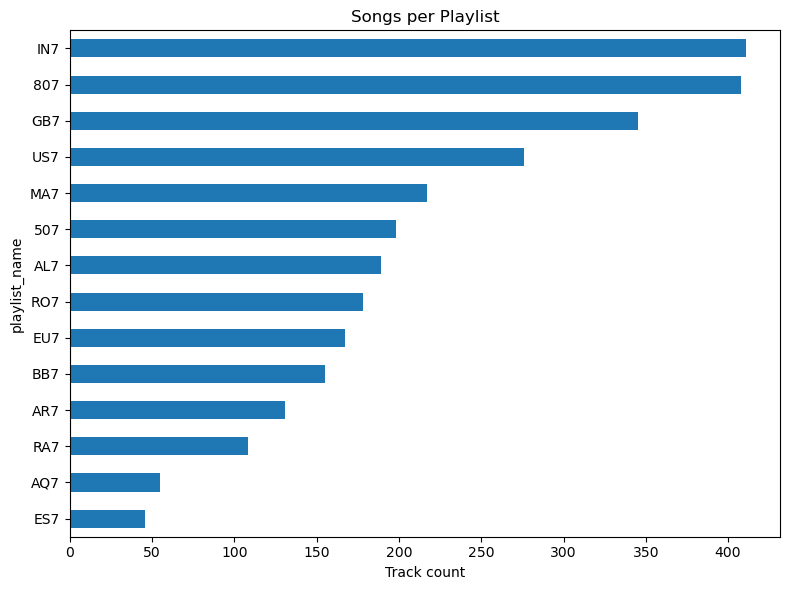

In [ ]:
playlist_counts = df.groupby('playlist_name')['track_id'].count().sort_values(ascending=False)
print(playlist_counts)

playlist_counts.plot(kind='barh', figsize=(8, 6))
plt.gca().invert_yaxis()
plt.xlabel('Track count')
plt.title('Songs per Playlist')
plt.tight_layout()
plt.show()

### Audio Feature Distributions

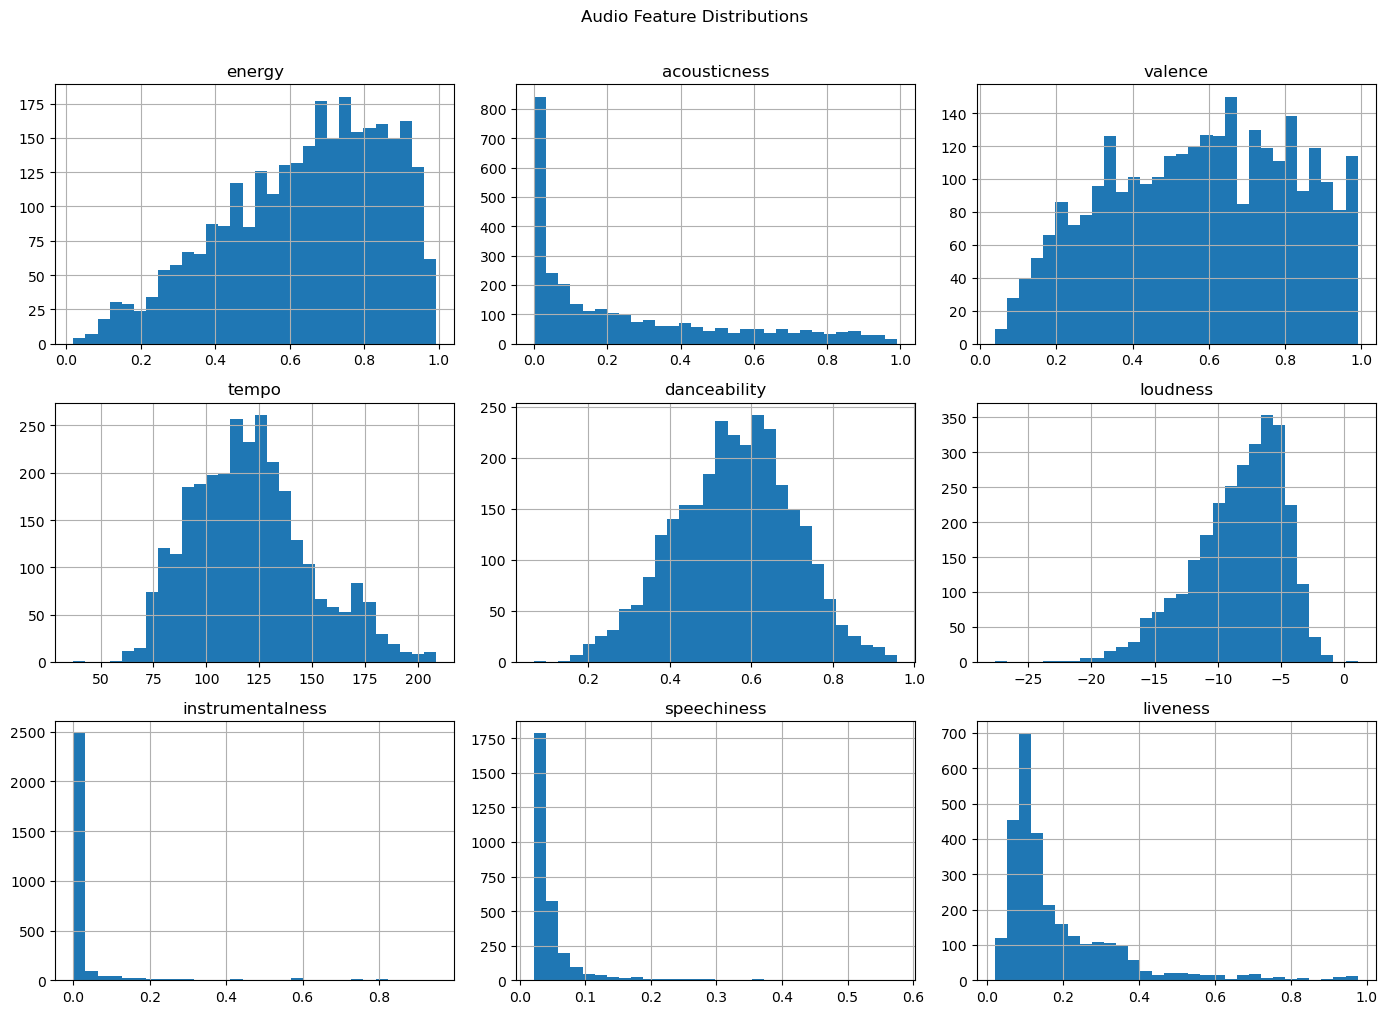

In [ ]:
features = ['energy', 'acousticness', 'valence', 'tempo', 'danceability',
            'loudness', 'instrumentalness', 'speechiness', 'liveness']

df[features].hist(bins=30, figsize=(14, 10))
plt.suptitle('Audio Feature Distributions', y=1.01)
plt.tight_layout()
plt.show()

### Zero-spike check for log-transform candidates

In [ ]:
for col in ['instrumentalness', 'speechiness']:
    zeros = (df[col] == 0).sum()
    print(f"{col}: {zeros} zeros ({zeros/len(df)*100:.1f}%)")

instrumentalness: 1441 zeros (50.0%)
speechiness: 0 zeros (0.0%)


### Observations

- Duplicates — 350 tracks appear in more than one playlist. We'll give the song to the playlist with less tracks. That brings us to ~2534 rows for modeling.
- Class imbalance — confirmed and significant. IN7 has 411 tracks, ES7 has 46 — a ~9x ratio. class_weight='balanced' is the right call.
- instrumentalness — 50% zeros, log1p transform stands.
- speechiness — zero zeros, so the log1p transform won't hurt but isn't strictly necessary. I will still apply it for consistency. 
- 14 playlists confirmed in the raw data, but after deduplication some tracks will be assigned to whichever playlist they appeared in first — worth keeping in mind when interpreting per-playlist metrics.



## Deduplication

In [ ]:
# ── Deduplication: assign duplicate tracks to smallest playlist ────────────
playlist_sizes = df.groupby('playlist_name')['track_id'].count().to_dict()

# For each track_id, keep the row belonging to the smallest playlist
df['playlist_size'] = df['playlist_name'].map(playlist_sizes)

df_sorted = df.sort_values('playlist_size', ascending=True)
df_dedup = df_sorted.drop_duplicates(subset='track_id', keep='first').drop(columns='playlist_size')
df_dedup = df_dedup.reset_index(drop=True)

print(f"Rows before dedup: {len(df)}")
print(f"Rows after dedup:  {len(df_dedup)}")
print(f"\nPlaylist distribution after dedup:")
print(df_dedup['playlist_name'].value_counts().sort_values(ascending=False))

Rows before dedup: 2884
Rows after dedup:  2534

Playlist distribution after dedup:
playlist_name
807    365
IN7    340
GB7    290
US7    244
MA7    200
507    182
AL7    161
RO7    150
EU7    145
BB7    142
AR7    117
RA7    105
AQ7     50
ES7     43
Name: count, dtype: int64


## Outlier Detection
### Decades-years

One of the criteria I use when placing a track in a playlist is the decade it belongs to.
My playlists are decade-aware by design — for example, `507` is built around Sinatra and
his contemporaries, so ideally every track should be from the 50s or early 60s. In practice,
though, I've often added remastered versions instead of originals, which quietly pushes the
release year into the 2000s or 2010s and pollutes the decade signal.

To fix this, I manually defined year bounds for each playlist based on their intended era,
then flagged any track falling outside those bounds as an outlier. The goal wasn't to be
perfectly strict — playlists like `AR7` or `EU7` naturally bleed into adjacent decades —
but to remove tracks that were clearly out of place. After several iterations of inspecting
the flagged tracks and adjusting the bounds, I settled on removing **237 outliers**,
bringing the dataset from 2534 to 2297 tracks.

In [ ]:
# ── Outlier detection: decade vs playlist expected era ────────────────────
decade_bounds = {
    '507': (1940, 2000),
    'GB7': (1955, 2000),
    'AQ7': (1970, 1995),
    'RO7': (1960, 1980),
    'BB7': (1970, 1996),
    'EU7': (1970, 1995),
    'AR7': (1980, 2005),
    'ES7': None,          # Spain-focused, no decade constraint
    'AL7': (1980, 2005),
    '807': (1970, 1995),
    'IN7': (1990, 2020),
    'US7': (1990, 2010),
    'MA7': (1990, 2010),
    'RA7': (1980, 2005),
}
def is_outlier(row):
    bounds = decade_bounds.get(row['playlist_name'])
    if bounds is None or pd.isnull(row['decade']):
        return False
    return row['decade'] < bounds[0] or row['decade'] > bounds[1]

df_dedup['is_decade_outlier'] = df_dedup.apply(is_outlier, axis=1)

print(f"Total outliers: {df_dedup['is_decade_outlier'].sum()}")
print(f"\nOutliers per playlist:")
print(df_dedup[df_dedup['is_decade_outlier']].groupby('playlist_name')['decade'].value_counts().sort_index())

Total outliers: 237

Outliers per playlist:
playlist_name  decade
507            1930       1
               2010      26
               2020       4
807            1960       3
               2000      32
               2010      24
               2020       4
AL7            1970       2
               2010      10
               2020       8
AQ7            1960       2
               2000       4
               2010       3
               2020       1
AR7            2010       5
               2020       3
BB7            1960       1
               2000       4
               2010       3
               2020       1
EU7            2000       7
               2010       7
               2020       1
GB7            1950       6
               2010      13
               2020       5
IN7            1980       1
MA7            2020       4
RA7            2010      18
               2020       6
RO7            1990      11
               2000       4
               2010       5
          

In [ ]:
df_clean = df_dedup[~df_dedup['is_decade_outlier']].reset_index(drop=True)

print(f"Rows before outlier removal: {len(df_dedup)}")
print(f"Rows after outlier removal:  {len(df_clean)}")
print(f"Outliers dropped:            {len(df_dedup) - len(df_clean)}")
print(f"\nFinal playlist distribution:")
print(df_clean['playlist_name'].value_counts().sort_values(ascending=False))

Rows before outlier removal: 2534
Rows after outlier removal:  2297
Outliers dropped:            237

Final playlist distribution:
playlist_name
IN7    339
807    302
GB7    266
US7    238
MA7    196
507    151
AL7    141
BB7    133
EU7    130
RO7    128
AR7    109
RA7     81
ES7     43
AQ7     40
Name: count, dtype: int64


### Audio Features

Beyond decade coherence, a track can also be a sonic outlier — a song that belongs to the
right era but simply doesn't sound like the rest of its playlist. A good example would be
a slow acoustic ballad sitting in a high-energy rock playlist, or a heavily instrumental
track in a vocal-driven one. These tracks won't necessarily be caught by year bounds, but
they can confuse the classifier by introducing contradictory signals within a playlist.

To detect these, I used an Isolation Forest — an algorithm that identifies tracks which are
anomalous across multiple audio features simultaneously. Rather than checking each feature
in isolation, it considers the full sonic profile of a track and flags those that are
hardest to group with their playlist neighbors. I ran it independently per playlist so that
"outlier" is always relative to that playlist's own sound, not the global dataset.

Given that some playlists are already small (ES7: 43, AQ7: 40), I kept the contamination
rate conservative at 5% to avoid over-pruning. As with the decade outliers, I'll inspect
what gets flagged before deciding what to drop.

Before anything, we'll do the log transformation we owe. 

In [ ]:
df_clean['instrumentalness_log'] = np.log1p(df_clean['instrumentalness'])
df_clean['speechiness_log'] = np.log1p(df_clean['speechiness'])

In [ ]:
from sklearn.ensemble import IsolationForest

AUDIO_FEATURES = [
    'energy', 'acousticness', 'valence', 'tempo', 'danceability',
    'loudness', 'instrumentalness_log', 'speechiness_log', 'liveness'
]

CONTAMINATION = 0.05

outlier_flags = []

for playlist, group in df_clean.groupby('playlist_name'):
    X_playlist = group[AUDIO_FEATURES].copy()
    
    iso = IsolationForest(contamination=CONTAMINATION, random_state=42)
    preds = iso.fit_predict(X_playlist)  # -1 = outlier, 1 = inlier
    
    flags = pd.Series(preds == -1, index=group.index)
    outlier_flags.append(flags)

df_clean['is_audio_outlier'] = pd.concat(outlier_flags).sort_index()

print(f"Total audio outliers flagged: {df_clean['is_audio_outlier'].sum()}")
print(f"\nPer playlist:")
print(df_clean.groupby('playlist_name')['is_audio_outlier'].sum().sort_values(ascending=False))

Total audio outliers flagged: 120

Per playlist:
playlist_name
IN7    17
807    16
GB7    14
US7    12
MA7    10
507     8
AL7     7
BB7     7
EU7     7
RO7     7
AR7     6
RA7     4
ES7     3
AQ7     2
Name: is_audio_outlier, dtype: int64


In [ ]:
audio_outliers = df_clean[df_clean['is_audio_outlier']].copy()

for playlist in df_clean['playlist_name'].unique():
    subset = audio_outliers[audio_outliers['playlist_name'] == playlist][
        ['track_name'] + AUDIO_FEATURES
    ].round(3)
    if len(subset) > 0:
        print(f"\n── {playlist} ──────────────────────────────")
        print(subset.to_string(index=False))


── ES7 ──────────────────────────────
          track_name  energy  acousticness  valence   tempo  danceability  loudness  instrumentalness_log  speechiness_log  liveness
19 Dias y 500 Noches   0.699         0.616    0.666  83.063         0.498    -9.078                 0.000            0.200     0.938
       Y Sin Embargo   0.480         0.701    0.349  77.979         0.485   -12.639                 0.000            0.299     0.721
              Cuándo   0.566         0.281    0.363 121.778         0.680    -6.950                 0.025            0.027     0.127

── AQ7 ──────────────────────────────
   track_name  energy  acousticness  valence   tempo  danceability  loudness  instrumentalness_log  speechiness_log  liveness
Cinema Verité   0.202         0.938    0.061  99.378         0.267   -14.270                 0.387            0.028     0.524
      Cheques   0.814         0.006    0.658 179.159         0.399    -5.659                 0.013            0.074     0.298

── RA7 ────

In [ ]:
df_model = df_clean[~df_clean['is_audio_outlier']].reset_index(drop=True)

print(f"Rows before audio outlier removal: {len(df_clean)}")
print(f"Rows after audio outlier removal:  {len(df_model)}")
print(f"\nFinal playlist distribution:")
print(df_model['playlist_name'].value_counts().sort_values(ascending=False))

Rows before audio outlier removal: 2297
Rows after audio outlier removal:  2177

Final playlist distribution:
playlist_name
IN7    322
807    286
GB7    252
US7    226
MA7    186
507    143
AL7    134
BB7    126
EU7    123
RO7    121
AR7    103
RA7     77
ES7     40
AQ7     38
Name: count, dtype: int64


In [ ]:
print(df_model.columns.tolist())

['track_id', 'track_name', 'artist_name', 'playlist_name', 'energy', 'acousticness', 'valence', 'tempo', 'danceability', 'loudness', 'instrumentalness', 'speechiness', 'liveness', 'mode', 'popularity_raw', 'duration_raw', 'release_year', 'decade', 'artist_genres', 'is_decade_outlier', 'instrumentalness_log', 'speechiness_log', 'is_audio_outlier']


## Feature Engineering

With the dataset clean and deduplicated, this section builds the full feature set for the classifier.
The goal is to give the model the richest possible signal about each track's sonic profile, era,
and cultural context — going beyond the raw audio features Spotify provides.

### Log Transforms (was done previously)
`instrumentalness` and `speechiness` are heavily zero-spiked, meaning most tracks cluster near zero
with a long right tail. Feeding these directly into a scaler would compress all the meaningful
variation into a tiny range. Applying `log1p` before scaling stretches that range back out and
gives the model a cleaner signal.

### Engineered Continuous Features
- **`energy_acousticness_ratio`**: The two strongest playlist separators from EDA combined into
  a single interaction term. High values indicate energetic, non-acoustic tracks (modern rock,
  hip hop); low values indicate calm, acoustic ones (507, GB7). Applied `log1p` to compress
  the range since near-zero acousticness values caused extreme spikes.
- **`tempo_normalized`**: Tempo has a much wider raw range than other features (65–200 BPM).
  Min-max normalized to 0–1 for consistency.
- **`decade_normalized`**: Same treatment as tempo — the raw decade values (1930–2020) are
  min-max normalized to 0–1 so the model treats era as a proportional signal rather than
  a large integer.

### Engineered Binary Features
These flags encode domain knowledge that the raw audio features can't capture on their own:

- **`is_argentine`** — flags tracks from Argentine artists or playlists centered on Argentine
  music (AR7, MA7, AQ7). Strong separator from the rest of the catalog.
- **`is_spanish_language`** — flags tracks with Spanish-language genre tags (rock en español,
  trova, latin rock, etc.). Helps isolate ES7, AQ7, AR7 and MA7 from English-language playlists
  with similar sonic profiles.
- **`is_british_invasion`** — flags tracks from core British Invasion artists (The Beatles,
  The Rolling Stones, The Who, The Kinks, and others). Primarily a GB7 signal.
- **`is_live`** — liveness > 0.8. Flags clearly live recordings rather than relying solely
  on the continuous liveness feature.
- **`is_instrumental`** — instrumentalness > 0.5. Flags tracks with little or no vocals,
  relevant for progressive rock and post-rock heavy playlists.
- **`is_long_track`** — duration > 6 minutes. Captures epic tracks typical of RO7 and EU7
  (Pink Floyd, Led Zeppelin, Joy Division).
- **`is_obscure`** — popularity < 20. Helps separate niche playlists like AQ7 and ES7
  from mainstream ones like 807 and IN7.
- **`artist_X`** If the song is played by an artist from my personal top 20 they get an id flag. For example artist_billy_joel

In [ ]:
# ── Engineered continuous features ────────────────────────────────────────
df_model['energy_acousticness_ratio'] = np.log1p(
    df_model['energy'] / (df_model['acousticness'] + 1e-6)
)

print(df_model['energy_acousticness_ratio'].describe().round(3))
df_model['tempo_normalized'] = (
    (df_model['tempo'] - df_model['tempo'].min()) /
    (df_model['tempo'].max() - df_model['tempo'].min())
)

df_model['decade_normalized'] = (
    (df_model['decade'] - df_model['decade'].min()) /
    (df_model['decade'].max() - df_model['decade'].min())
)

# ── Engineered binary features ─────────────────────────────────────────────
argentine_playlists = ['MA7', 'AR7', 'AQ7']
df_model['is_argentine'] = (
    df_model['artist_genres'].fillna('').str.contains('argentine rock', case=False) |
    df_model['playlist_name'].isin(argentine_playlists)
).astype(int)

spanish_language_tags = [
    'rock en español', 'latin rock', 'trova', 'latin pop', 'nueva trova',
    'latin alternative', 'latin folk', 'folklore argentino', 'latin indie'
]
df_model['is_spanish_language'] = df_model['artist_genres'].fillna('').apply(
    lambda g: int(any(tag in g.lower() for tag in spanish_language_tags))
)

british_invasion_artists = [
    'the beatles', 'the rolling stones', 'the who', 'the kinks',
    'the animals', 'the yardbirds', 'cream', 'the dave clark five',
    "herman's hermits", 'the hollies', 'the small faces',
    'the spencer davis group'
]
df_model['is_british_invasion'] = df_model['artist_name'].fillna('').apply(
    lambda a: int(a.lower() in british_invasion_artists)
)

df_model['is_live'] = (df_model['liveness'] > 0.8).astype(int)

df_model['is_instrumental'] = (df_model['instrumentalness'] > 0.5).astype(int)

df_model['is_long_track'] = (df_model['duration_raw'] > 6).astype(int)

df_model['is_obscure'] = (df_model['popularity_raw'] < 20).astype(int)

# ── Top-N artist binary encoding ───────────────────────────────────────────

TOP_N_ARTISTS = 20

artist_counts = df_model['artist_name'].value_counts()
top_artists = artist_counts.head(TOP_N_ARTISTS).index.tolist()

for artist in top_artists:
    col_name = 'artist_' + artist.lower().replace(' ', '_').replace('-', '_').replace('.', '').replace("'", '')
    df_model[col_name] = (df_model['artist_name'] == artist).astype(int)

artist_cols = ['artist_' + a.lower().replace(' ', '_').replace('-', '_').replace('.', '').replace("'", '') 
               for a in top_artists]

print("Artist flag counts:")
for col in artist_cols:
    print(f"  {col}: {df_model[col].sum()}")

# ── Sanity check ───────────────────────────────────────────────────────────
engineered_binary = [
    'is_argentine', 'is_spanish_language', 'is_british_invasion',
    'is_live', 'is_instrumental', 'is_long_track', 'is_obscure'
]

print("Binary feature counts:")
for col in engineered_binary:
    print(f"  {col}: {df_model[col].sum()}")

print(f"\nEngineered continuous sample:")
print(df_model[['energy_acousticness_ratio', 'tempo_normalized', 'decade_normalized']].describe().round(3))

count    2177.000
mean        2.465
std         2.231
min         0.020
25%         0.879
50%         1.767
75%         3.460
max        13.803
Name: energy_acousticness_ratio, dtype: float64
Artist flag counts:
  artist_the_beatles: 66
  artist_billy_joel: 43
  artist_the_rolling_stones: 36
  artist_red_hot_chili_peppers: 25
  artist_oasis: 24
  artist_andrés_calamaro: 23
  artist_led_zeppelin: 23
  artist_charly_garcía: 20
  artist_bruce_springsteen: 18
  artist_fito_paez: 18
  artist_radiohead: 17
  artist_arctic_monkeys: 17
  artist_blink_182: 15
  artist_bob_dylan: 14
  artist_queen: 14
  artist_soda_stereo: 13
  artist_u2: 13
  artist_frank_sinatra: 12
  artist_green_day: 12
  artist_eminem: 12
Binary feature counts:
  is_argentine: 328
  is_spanish_language: 259
  is_british_invasion: 121
  is_live: 19
  is_instrumental: 37
  is_long_track: 87
  is_obscure: 38

Engineered continuous sample:
       energy_acousticness_ratio  tempo_normalized  decade_normalized
count              

## Preprocessing for Model training
### Dropping unnecesary columns


In [ ]:
cols_to_drop = [
    'is_decade_outlier', 'is_audio_outlier', 'genre_families',
    'instrumentalness', 'speechiness',
    'release_year',
]

df_model = df_model.drop(columns=cols_to_drop, errors='ignore')
print(f"Columns remaining: {len(df_model.columns)}")
print(df_model.columns.tolist())

Columns remaining: 48
['track_id', 'track_name', 'artist_name', 'playlist_name', 'energy', 'acousticness', 'valence', 'tempo', 'danceability', 'loudness', 'liveness', 'mode', 'popularity_raw', 'duration_raw', 'decade', 'artist_genres', 'instrumentalness_log', 'speechiness_log', 'energy_acousticness_ratio', 'tempo_normalized', 'decade_normalized', 'is_argentine', 'is_spanish_language', 'is_british_invasion', 'is_live', 'is_instrumental', 'is_long_track', 'is_obscure', 'artist_the_beatles', 'artist_billy_joel', 'artist_the_rolling_stones', 'artist_red_hot_chili_peppers', 'artist_oasis', 'artist_andrés_calamaro', 'artist_led_zeppelin', 'artist_charly_garcía', 'artist_bruce_springsteen', 'artist_fito_paez', 'artist_radiohead', 'artist_arctic_monkeys', 'artist_blink_182', 'artist_bob_dylan', 'artist_queen', 'artist_soda_stereo', 'artist_u2', 'artist_frank_sinatra', 'artist_green_day', 'artist_eminem']


### Categorical Encoding

With the audio features and engineered flags in place, this section handles the two remaining
categorical signals: artist genres and artist identity.

#### Genre Family Encoding
The raw `artist_genres` field from `dim_artist` contains comma-separated Spotify genre tags —
highly granular labels like `"old school hip hop, gangster rap, west coast hip hop"` or
`"new wave, synthpop, post-punk"`. Using these directly would produce hundreds of sparse binary
columns with little individual signal.

Instead, I grouped the ~300 unique tags into 16 genre families that reflect the broad stylistic
categories represented across my playlists: `classic_rock`, `hip_hop`, `new_wave`, `punk`,
`grunge_alt`, `emo_pop_punk`, `britpop_indie`, `soul_rnb`, `jazz`, `folk_country`,
`latin_rock`, `latin_pop_trova`, `pop_dance`, `glam`, `reggae`, and `standards`.

A few deliberate decisions in the mapping:
- `rap_rock` and `nu_metal` → `grunge_alt` (Linkin Park, Limp Bizkit live in US7 alongside grunge)
- `emo` and `pop_punk` → their own family (dominant in US7, distinct enough to separate)
- `ambient` and `krautrock` → `new_wave` (Brian Eno is the only case, firmly EU7-adjacent)

474 tracks had no genre data in `dim_artist` — these receive all-zero genre flags.
This is a data gap upstream and not something we can recover here.

#### Top-20 Artist Encoding
Beyond genre families, artist identity itself is a strong playlist signal — The Beatles belong
in GB7, Eminem in RA7, Soda Stereo in AR7. With ~900 unique artists a full binary encoding
would be impractical, so I kept only the top 20 most represented artists in the dataset,
each getting their own binary flag.

The top 20 were validated manually — every artist is clearly anchored to one or two specific
playlists rather than scattered across the catalog, making these flags genuinely informative
rather than noisy.

In [ ]:
genre_families = {
    'hip_hop': [
        'hip hop', 'rap', 'old school hip hop', 'east coast hip hop', 'west coast hip hop',
        'gangster rap', 'hardcore hip hop', 'g-funk', 'southern hip hop', 'horrorcore',
        'jazz rap', 'alternative hip hop', 'boom bap', 'new jack swing'
    ],
    'classic_rock': [
        'classic rock', 'hard rock', 'blues rock', 'acid rock', 'psychedelic rock',
        'progressive rock', 'southern rock', 'aor', 'arena rock', 'surf rock',
        'blues', 'classic blues', 'soul blues', 'country blues', 'blues rock',
        'ambient', 'krautrock', 'space music', 'drone', 'minimalism'
    ],
    'new_wave': [
        'new wave', 'synthpop', 'post-punk', 'darkwave', 'gothic rock', 'cold wave',
        'deathrock', 'madchester', 'ambient', 'krautrock', 'art rock', 'space music'
    ],
    'punk': [
        'punk', 'proto-punk', 'garage rock', 'skate punk', 'hardcore punk', 'hardcore',
        'riot grrrl'
    ],
    'grunge_alt': [
        'grunge', 'post-grunge', 'alternative rock', 'indie rock', 'shoegaze',
        'dream pop', 'noise rock', 'funk rock', 'nu metal', 'rap metal',
        'rap rock', 'alternative metal'
    ],
    'emo_pop_punk': [
        'emo', 'pop punk'
    ],
    'britpop_indie': [
        'britpop', 'jangle pop', 'indie', 'indie pop', 'lo-fi indie', 'power pop',
        'anti-folk', 'bedroom pop', 'neo-psychedelic', 'slowcore'
    ],
    'soul_rnb': [
        'soul', 'classic soul', 'motown', 'northern soul', 'philly soul', 'r&b',
        'neo soul', 'quiet storm', 'retro soul', 'indie soul', 'funk', 'disco funk'
    ],
    'jazz': [
        'jazz', 'vocal jazz', 'soul jazz', 'smooth jazz', 'acid jazz',
        'big band', 'swing music', 'french jazz', 'jazz pop', 'jazz funk'
    ],
    'folk_country': [
        'folk', 'folk rock', 'country', 'country rock', 'americana', 'alt country',
        'roots rock', 'singer-songwriter', 'bluegrass', 'newgrass', 'indie folk',
        'folk pop', 'baroque pop', 'soft rock', 'yacht rock', 'adult standards',
        'soft pop', 'acoustic pop'
    ],
    'latin_rock': [
        'rock en español', 'latin rock', 'argentine rock', 'latin alternative',
        'latin indie', 'mexican rock', 'brazilian rock', 'latin folk',
        'murga', 'ska', 'ska punk', 'reggae en español'
    ],
    'latin_pop_trova': [
        'latin pop', 'trova', 'nueva trova', 'folklore argentino', 'tango',
        'candombe', 'bolero', 'latin folklore', 'folclor andino', 'chamamé',
        'colombian pop', 'latin pop', 'cumbia', 'bachata', 'salsa', 'merengue',
        'ranchera', 'mariachi', 'grupera'
    ],
    'pop_dance': [
        'pop', 'pop rock', 'eurodance', 'europop', 'disco', 'italo disco',
        'edm', 'hi-nrg', 'italo dance', 'swedish pop', 'french pop',
        'variété française', 'chanson', 'schlager', 'dance pop'
    ],
    'glam': [
        'glam rock', 'glam metal', 'art pop', 'proto-punk'
    ],
    'reggae': [
        'reggae', 'roots reggae', 'reggae rock', 'calypso', 'afropop'
    ],
    'standards': [
        'adult standards', 'doo-wop', 'rockabilly', 'rock and roll',
        'christmas', 'exotica', 'native american music', 'musicals',
        'traditional gospel'
    ]
}

def assign_genre_families(genre_string):
    if not genre_string or genre_string == '':
        return []
    tags = [t.strip().lower() for t in genre_string.split(',')]
    assigned = []
    for family, keywords in genre_families.items():
        if any(tag in keywords for tag in tags):
            assigned.append(family)
    return assigned

df_model['genre_families'] = df_model['artist_genres'].fillna('').apply(assign_genre_families)

# Binary encode
all_families = list(genre_families.keys())
for family in all_families:
    df_model[f'genre_{family}'] = df_model['genre_families'].apply(lambda x: int(family in x))

# Sanity check
print("Genre family coverage:")
genre_cols = [f'genre_{f}' for f in all_families]
print(df_model[genre_cols].sum().sort_values(ascending=False))

print(f"\nTracks with no genre family assigned: {(df_model[genre_cols].sum(axis=1) == 0).sum()}")

# Drop intermediate list column
df_model = df_model.drop(columns='genre_families', errors='ignore')

# Check what genres aren't being captured
unassigned = df_model[df_model[genre_cols].sum(axis=1) == 0]['artist_genres'].value_counts()
print("\nUnassigned genre strings:")
print(unassigned)

Genre family coverage:
genre_classic_rock       360
genre_latin_rock         338
genre_folk_country       331
genre_new_wave           191
genre_britpop_indie      171
genre_grunge_alt         169
genre_punk               118
genre_standards          108
genre_glam                98
genre_latin_pop_trova     91
genre_soul_rnb            72
genre_hip_hop             65
genre_jazz                61
genre_emo_pop_punk        53
genre_pop_dance           49
genre_reggae              13
dtype: int64

Tracks with no genre family assigned: 496

Unassigned genre strings:
artist_genres
                                      474
rock                                   14
drum and bass                           2
classic country                         2
french house, electronic, electro       2
classic country, country christian      1
jam band                                1
Name: count, dtype: int64


In [ ]:
genre_families['classic_rock'].append('rock')
genre_families['folk_country'].extend(['classic country', 'classic country, country christian', 'jam band'])
genre_families['pop_dance'].extend(['drum and bass', 'french house', 'electronic', 'electro'])

# Re-run encoding with patched mapping
df_model['genre_families'] = df_model['artist_genres'].fillna('').apply(assign_genre_families)

for family in all_families:
    df_model[f'genre_{family}'] = df_model['genre_families'].apply(lambda x: int(family in x))

df_model = df_model.drop(columns='genre_families', errors='ignore')

print("Genre family coverage:")
print(df_model[genre_cols].sum().sort_values(ascending=False))
print(f"\nTracks with no genre family assigned: {(df_model[genre_cols].sum(axis=1) == 0).sum()}")

Genre family coverage:
genre_classic_rock       476
genre_folk_country       339
genre_latin_rock         338
genre_new_wave           191
genre_britpop_indie      171
genre_grunge_alt         169
genre_punk               118
genre_standards          108
genre_glam                98
genre_latin_pop_trova     91
genre_soul_rnb            72
genre_hip_hop             65
genre_jazz                61
genre_emo_pop_punk        53
genre_pop_dance           53
genre_reggae              13
dtype: int64

Tracks with no genre family assigned: 474


### Memory Optimization

In [ ]:
def optimize_memory(df):
    for col in df.select_dtypes(include=['float64']).columns:
        df[col] = df[col].astype('float32')
    for col in df.select_dtypes(include=['int64']).columns:
        df[col] = df[col].astype('int8')
    return df

before = df_model.memory_usage(deep=True).sum() / 1024**2
df_model = optimize_memory(df_model)
after = df_model.memory_usage(deep=True).sum() / 1024**2

print(f"Memory before: {before:.2f} MB")
print(f"Memory after:  {after:.2f} MB")
print(f"Reduction:     {(1 - after/before)*100:.1f}%")

Memory before: 1.45 MB
Memory after:  1.03 MB
Reduction:     28.5%


### Define feature matrix and target

In [ ]:
exclude_cols = ['track_id', 'track_name', 'artist_name', 'artist_genres', 'playlist_name']

feature_cols = [col for col in df_model.columns if col not in exclude_cols]
target_col = 'playlist_name'

X = df_model[feature_cols]
y = df_model[target_col]

print(f"Features: {len(feature_cols)}")
print(f"Samples:  {len(X)}")
print(f"Target classes: {y.nunique()}")

Features: 59
Samples:  2177
Target classes: 14


### Stratified Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]} samples")
print(f"Test:  {X_test.shape[0]} samples")
print(f"\nClass distribution — Train:")
print(y_train.value_counts().sort_values(ascending=False))
print(f"\nClass distribution — Test:")
print(y_test.value_counts().sort_values(ascending=False))

Train: 1741 samples
Test:  436 samples

Class distribution — Train:
playlist_name
IN7    257
807    229
GB7    202
US7    181
MA7    149
507    114
AL7    107
BB7    101
EU7     98
RO7     97
AR7     82
RA7     62
ES7     32
AQ7     30
Name: count, dtype: int64

Class distribution — Test:
playlist_name
IN7    65
807    57
GB7    50
US7    45
MA7    37
507    29
AL7    27
EU7    25
BB7    25
RO7    24
AR7    21
RA7    15
AQ7     8
ES7     8
Name: count, dtype: int64


### Standard Scaler


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=feature_cols)

print("Scaling done.")
print(f"Train shape: {X_train_scaled.shape}")
print(f"Test shape:  {X_test_scaled.shape}")

Scaling done.
Train shape: (1741, 59)
Test shape:  (436, 59)


## Evaluation Framework

Before evaluating models, let's define the metrics and how to interpret them in this 14-class context.

### Primary metric — Macro F1
F1 is the harmonic mean of Precision and Recall. The **macro** variant averages F1 **unweighted across all 14 playlists** — so a small playlist like AQ7 (≈8 test samples) counts as much as IN7 (the largest). This is the right primary metric here because we care about getting *each* playlist right, not just the numerically dominant ones.

> **Interpret as:** 0.0 = predicts nothing correctly, 1.0 = perfect. A score of 0.75 means the model is good on average, but individual playlists will vary widely above and below.

### Supporting metric — Accuracy
Proportion of all predictions that are correct. Easy to read but **misleading with class imbalance**: a model that always predicts IN7 scores ≈15% with zero real knowledge. I will use accuracy as a sanity check alongside F1, not as the headline.

### Supporting metric — Weighted F1
Like Macro F1 but **weighted by support** (number of true samples per class). Larger playlists pull the score more. A big gap between Weighted F1 and Macro F1 signals the model does well on large playlists but struggles on small ones (or vice versa).

### Supporting metric — Confusion Matrix
A 14×14 grid where row = true playlist, column = predicted playlist. Diagonal = correct predictions. Off-diagonal cells reveal *which* playlists bleed into which — the most actionable output for understanding where the model fails.

### Overfitting check
For each model we compare **Train vs Test** across all three metrics. A large gap (>15 pp on accuracy or >0.15 on Macro F1) indicates overfitting — the model memorised training data rather than learning generalizable patterns. A small gap with a low test score indicates underfitting.

## Model 1 — Baseline (Random Chance)

Most frequent class: IN7 (14.8% of train)
Random chance:       7.1%

Metric                  Train     Test      Gap
----------------------------------------------
Accuracy                14.8%    14.9%    -0.1%
Macro F1                0.018    0.019   -0.000
Weighted F1             0.038    0.039   -0.001


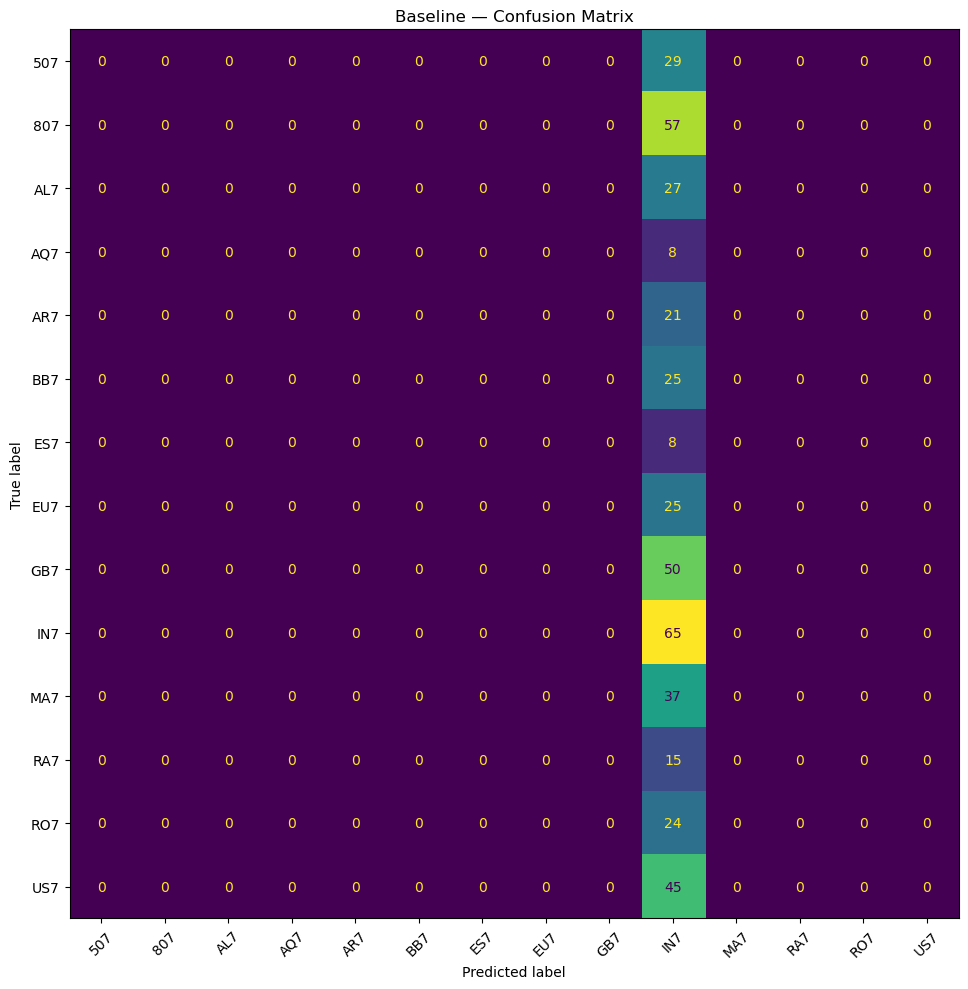

In [ ]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, accuracy_score, ConfusionMatrixDisplay

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_scaled, y_train)

y_pred_dummy_train = dummy.predict(X_train_scaled)
y_pred_dummy_test  = dummy.predict(X_test_scaled)

most_frequent_class = y_train.value_counts().index[0]
most_frequent_share = y_train.value_counts().iloc[0] / len(y_train)

# ── Metrics ───────────────────────────────────────────────────────────────
train_acc      = accuracy_score(y_train, y_pred_dummy_train)
test_acc       = accuracy_score(y_test,  y_pred_dummy_test)
train_macro_f1 = f1_score(y_train, y_pred_dummy_train, average='macro',    zero_division=0)
test_macro_f1  = f1_score(y_test,  y_pred_dummy_test,  average='macro',    zero_division=0)
train_w_f1     = f1_score(y_train, y_pred_dummy_train, average='weighted', zero_division=0)
test_w_f1      = f1_score(y_test,  y_pred_dummy_test,  average='weighted', zero_division=0)

print(f"Most frequent class: {most_frequent_class} ({most_frequent_share*100:.1f}% of train)")
print(f"Random chance:       {1/y.nunique()*100:.1f}%\n")
print(f"{'Metric':<20} {'Train':>8} {'Test':>8} {'Gap':>8}")
print("-" * 46)
print(f"{'Accuracy':<20} {train_acc*100:>7.1f}% {test_acc*100:>7.1f}% {(train_acc - test_acc)*100:>+7.1f}%")
print(f"{'Macro F1':<20} {train_macro_f1:>8.3f} {test_macro_f1:>8.3f} {train_macro_f1 - test_macro_f1:>+8.3f}")
print(f"{'Weighted F1':<20} {train_w_f1:>8.3f} {test_w_f1:>8.3f} {train_w_f1 - test_w_f1:>+8.3f}")

# ── Confusion Matrix ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dummy_test,
    ax=ax, colorbar=False, xticks_rotation=45
)
ax.set_title("Baseline — Confusion Matrix")
plt.tight_layout()
plt.show()

#### Analysis: Baseline

The baseline sets the floor for model evaluation. A naive classifier that always predicts
the most frequent playlist — IN7, which represents 14.8% of the training data — achieves
**14.9% accuracy**, a **Macro F1 of 0.019**, and a **Weighted F1 of 0.039**. Random
guessing across all 14 playlists would yield just 7.1%.

The near-zero Macro F1 is the most telling number: always predicting IN7 means 13 out of
14 playlists are never predicted at all, so their F1 scores are zero. The tiny positive
value comes entirely from IN7 itself. Any meaningful model must not only beat 14.9%
accuracy but drive Macro F1 well above 0.019 — meaning it must learn signal for
every playlist, not just the dominant one.

The negligible train/test gap (-0.1% accuracy, -0.000 Macro F1) confirms there is no
overfitting here — the model has nothing to memorize.

## Model 2: Random Forest

Metric                  Train     Test      Gap
----------------------------------------------
Accuracy               100.0%    74.3%   +25.7%
Macro F1                1.000    0.747   +0.253
Weighted F1             1.000    0.731   +0.269

Per-Playlist F1
----------------------------------------------
  RA7    1.000  ██████████████████████████████
  AQ7    0.933  ████████████████████████████
  ES7    0.933  ████████████████████████████
  MA7    0.875  ██████████████████████████
  IN7    0.829  ████████████████████████
  RO7    0.766  ██████████████████████
  US7    0.764  ██████████████████████
  GB7    0.739  ██████████████████████
  AR7    0.737  ██████████████████████
  507    0.731  █████████████████████
  807    0.676  ████████████████████
  BB7    0.667  ████████████████████
  AL7    0.450  █████████████
  EU7    0.353  ██████████


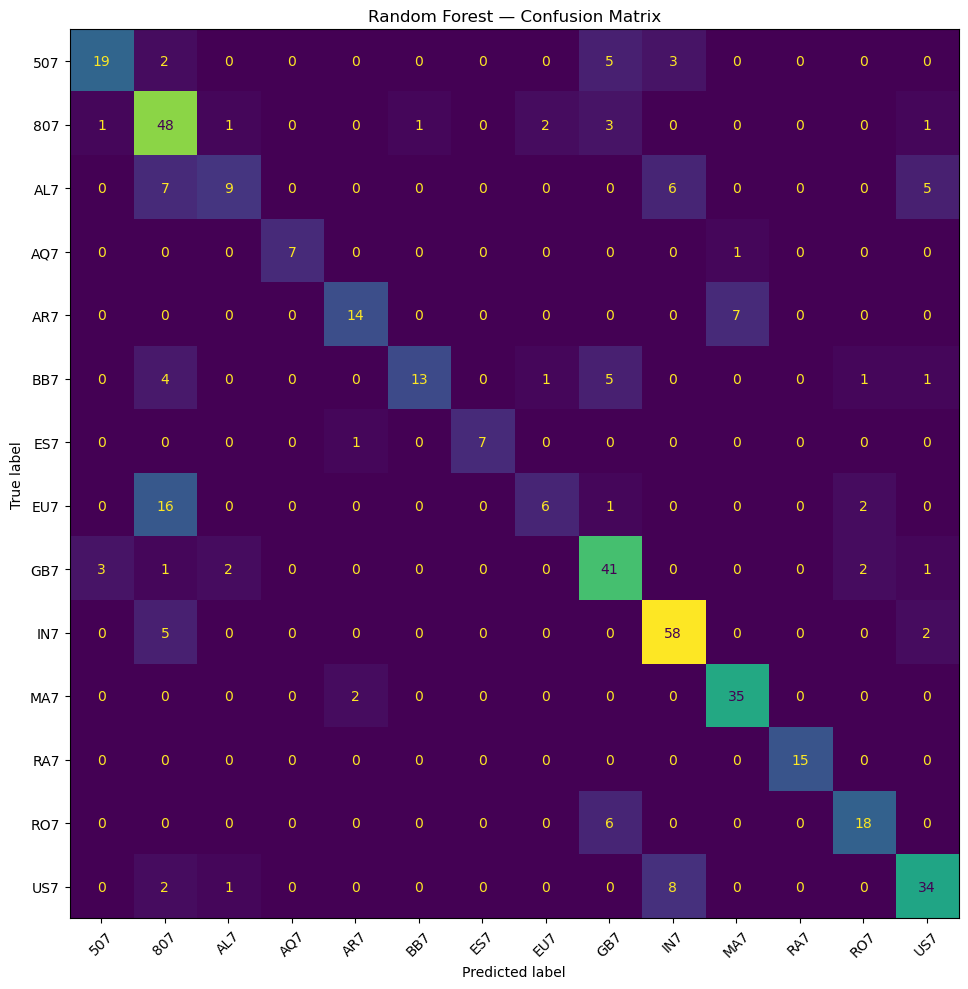

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, accuracy_score, ConfusionMatrixDisplay, classification_report

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train)
y_pred_rf       = rf.predict(X_test_scaled)
y_pred_rf_train = rf.predict(X_train_scaled)

# ── Metrics table ─────────────────────────────────────────────────────────
train_acc      = accuracy_score(y_train, y_pred_rf_train)
test_acc       = accuracy_score(y_test,  y_pred_rf)
train_macro_f1 = f1_score(y_train, y_pred_rf_train, average='macro')
test_macro_f1  = f1_score(y_test,  y_pred_rf,       average='macro')
train_w_f1     = f1_score(y_train, y_pred_rf_train, average='weighted')
test_w_f1      = f1_score(y_test,  y_pred_rf,       average='weighted')

print(f"{'Metric':<20} {'Train':>8} {'Test':>8} {'Gap':>8}")
print("-" * 46)
print(f"{'Accuracy':<20} {train_acc*100:>7.1f}% {test_acc*100:>7.1f}% {(train_acc-test_acc)*100:>+7.1f}%")
print(f"{'Macro F1':<20} {train_macro_f1:>8.3f} {test_macro_f1:>8.3f} {train_macro_f1-test_macro_f1:>+8.3f}")
print(f"{'Weighted F1':<20} {train_w_f1:>8.3f} {test_w_f1:>8.3f} {train_w_f1-test_w_f1:>+8.3f}")

# ── F1 per playlist ───────────────────────────────────────────────────────
print(f"\n{'Per-Playlist F1':}")
print("-" * 46)
report = classification_report(y_test, y_pred_rf, output_dict=True)
playlist_f1 = {k: v['f1-score'] for k, v in report.items() 
               if k not in ['accuracy', 'macro avg', 'weighted avg']}
playlist_f1_sorted = dict(sorted(playlist_f1.items(), key=lambda x: x[1], reverse=True))
for playlist, f1 in playlist_f1_sorted.items():
    bar = '█' * int(f1 * 30)
    print(f"  {playlist:<6} {f1:.3f}  {bar}")

# ── Confusion Matrix ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    ax=ax, colorbar=False, xticks_rotation=45
)
ax.set_title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.show()

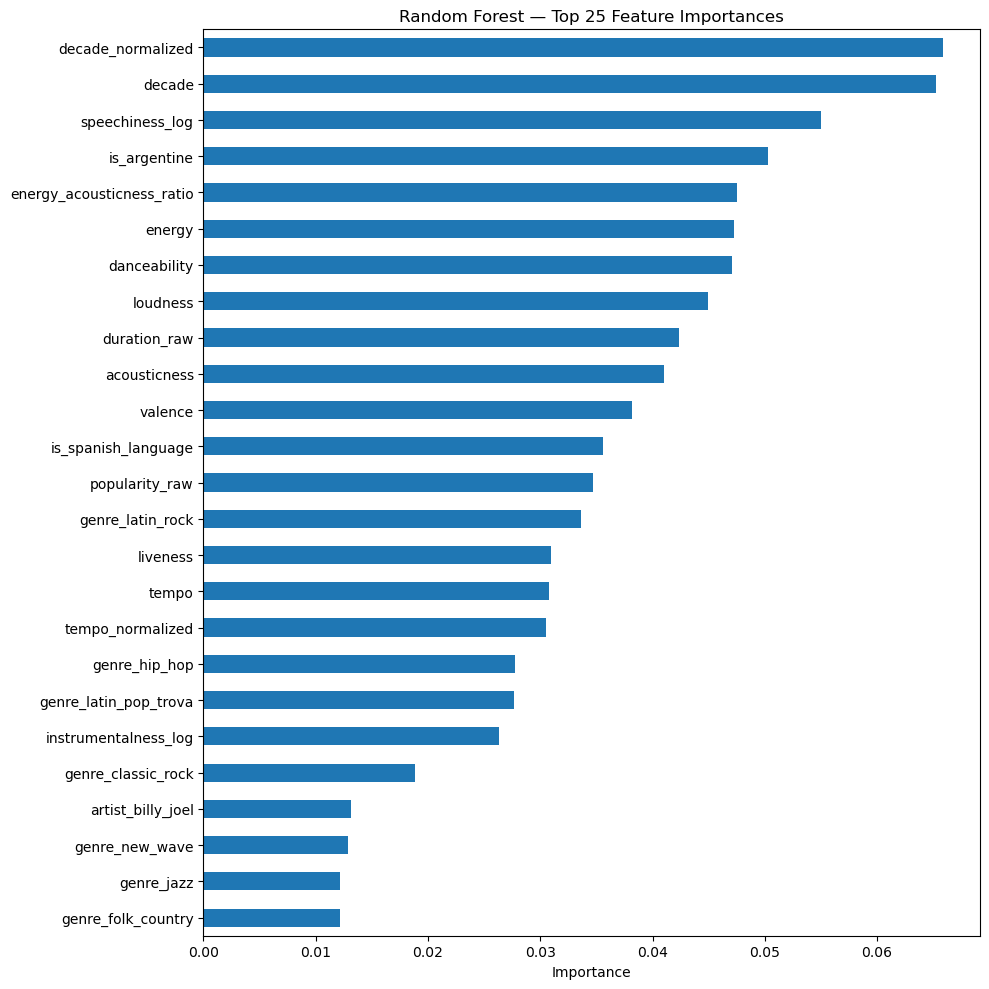

In [ ]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 10))
importances.head(25).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Random Forest — Top 25 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import LabelBinarizer

y_proba_rf = rf.predict_proba(X_test_scaled)
classes = rf.classes_

def top_k_accuracy(y_true, y_proba, classes, k=3):
    correct = 0
    for true_label, probs in zip(y_true, y_proba):
        top_k_indices = probs.argsort()[-k:][::-1]
        top_k_labels = classes[top_k_indices]
        if true_label in top_k_labels:
            correct += 1
    return correct / len(y_true)

top1 = top_k_accuracy(y_test.values, y_proba_rf, classes, k=1)
top3 = top_k_accuracy(y_test.values, y_proba_rf, classes, k=3)
top5 = top_k_accuracy(y_test.values, y_proba_rf, classes, k=5)

print(f"Top-1 Accuracy: {top1*100:.1f}%")
print(f"Top-3 Accuracy: {top3*100:.1f}%")
print(f"Top-5 Accuracy: {top5*100:.1f}%")

Top-1 Accuracy: 74.8%
Top-3 Accuracy: 95.2%
Top-5 Accuracy: 98.6%


#### Analysis: Model 1 — Random Forest

| Metric      | Train  | Test  | Gap    |
|-------------|--------|-------|--------|
| Accuracy    | 100.0% | 74.3% | +25.7% |
| Macro F1    | 1.000  | 0.747 | +0.253 |
| Weighted F1 | 1.000  | 0.731 | +0.269 |

The Random Forest achieves **74.3% accuracy** and a **Macro F1 of 0.747** on the test set —
a dramatic improvement over the baseline's 0.019. The high Macro F1 is particularly
meaningful here: it means the model is learning signal for all 14 playlists, not just
the dominant ones. The small gap between Macro F1 (0.747) and Weighted F1 (0.731) suggests
performance is fairly consistent across playlist sizes — small playlists like AQ7 and ES7
are not being sacrificed for the larger ones.

The elephant in the room is the **25.7% overfitting gap** — 100% train accuracy against
74.3% test is a classic Random Forest pattern with unlimited tree depth. The trees memorize
the training set perfectly but fail to generalize that knowledge to unseen tracks.

**Standout playlists:**
- `RA7` is perfect — 1.00 F1. Hip hop has a completely distinct sonic and genre profile
  that the model separates without any confusion.
- `AQ7` and `ES7` both hit 0.93 F1 despite being the two smallest playlists (8 samples
  each in test). The `is_argentine` and `is_spanish_language` flags are doing exactly
  what they were designed to do.
- `MA7` reaches 0.88 F1 with near-perfect recall (0.95) — the Argentine rock + 90s era
  combination is a strong signal.
- `IN7` at 0.83 F1 is solid given it's the largest and most sonically diverse playlist.

**Struggling playlists:**
- `EU7` is the weakest at 0.35 F1 — low recall (0.24) suggests the model frequently
  misclassifies EU7 tracks into other playlists. The late 70s/80s new wave sound sits
  uncomfortably close to the general 80s profile of 807.
- `AL7` at 0.45 F1 suffers the same problem — 80s/90s British rock overlaps heavily
  with GB7, RO7, and IN7.
- `BB7` has strong precision (0.93) but poor recall (0.52) — the model only predicts
  BB7 when very confident, missing half the actual BB7 tracks.

**Feature importance:**
- `decade_normalized` and `decade` together are the dominant signal (0.065 each) —
  confirming the EDA finding that era is the strongest playlist separator.
- `speechiness_log` ranks third (0.055) — driven almost entirely by RA7's hip hop content.
- `is_argentine` (0.050) is the top engineered binary flag, validating the decision to
  add domain knowledge beyond raw audio features.
- `energy_acousticness_ratio` (0.047) performs on par with raw `energy` and `danceability`,
  confirming the interaction term adds signal rather than just duplicating existing features.
- Artist-level flags appear lower in importance with RF, with `artist_billy_joel` (0.013)
  being the only top-20 artist to crack the top 25 — suggesting genre families carry more
  generalizable signal than individual artist identity for this model.

**Overfitting note:** XGBoost with its built-in regularization should reduce the train/test
gap while hopefully maintaining or improving test accuracy.

## Model 3 — XGBoost


Metric                  Train     Test      Gap
----------------------------------------------
Accuracy               100.0%    73.2%   +26.8%
Macro F1                1.000    0.740   +0.260
Weighted F1             1.000    0.729   +0.271

Per-Playlist F1
----------------------------------------------
  RA7    0.968  █████████████████████████████
  ES7    0.933  ████████████████████████████
  MA7    0.889  ██████████████████████████
  IN7    0.872  ██████████████████████████
  507    0.807  ████████████████████████
  AQ7    0.800  ████████████████████████
  US7    0.759  ██████████████████████
  AR7    0.743  ██████████████████████
  GB7    0.710  █████████████████████
  BB7    0.652  ███████████████████
  RO7    0.627  ██████████████████
  807    0.583  █████████████████
  AL7    0.571  █████████████████
  EU7    0.444  █████████████


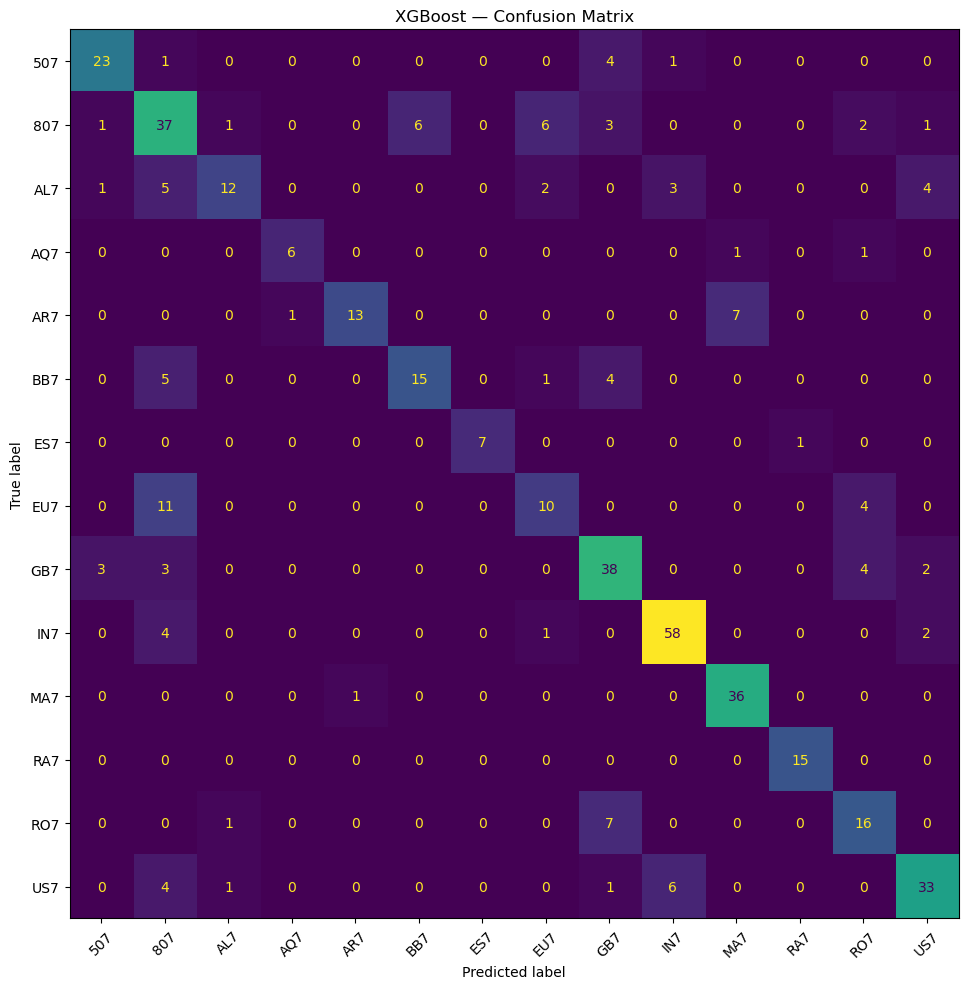

In [ ]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import f1_score, accuracy_score, ConfusionMatrixDisplay, classification_report

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc  = le.transform(y_test)

sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_enc)

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train_scaled, y_train_enc, sample_weight=sample_weights)

y_pred_xgb_enc       = xgb.predict(X_test_scaled)
y_pred_xgb           = le.inverse_transform(y_pred_xgb_enc)
y_pred_xgb_train_enc = xgb.predict(X_train_scaled)
y_pred_xgb_train     = le.inverse_transform(y_pred_xgb_train_enc)

# ── Metrics table ─────────────────────────────────────────────────────────
train_acc      = accuracy_score(y_train, y_pred_xgb_train)
test_acc       = accuracy_score(y_test,  y_pred_xgb)
train_macro_f1 = f1_score(y_train, y_pred_xgb_train, average='macro')
test_macro_f1  = f1_score(y_test,  y_pred_xgb,       average='macro')
train_w_f1     = f1_score(y_train, y_pred_xgb_train, average='weighted')
test_w_f1      = f1_score(y_test,  y_pred_xgb,       average='weighted')

print(f"{'Metric':<20} {'Train':>8} {'Test':>8} {'Gap':>8}")
print("-" * 46)
print(f"{'Accuracy':<20} {train_acc*100:>7.1f}% {test_acc*100:>7.1f}% {(train_acc-test_acc)*100:>+7.1f}%")
print(f"{'Macro F1':<20} {train_macro_f1:>8.3f} {test_macro_f1:>8.3f} {train_macro_f1-test_macro_f1:>+8.3f}")
print(f"{'Weighted F1':<20} {train_w_f1:>8.3f} {test_w_f1:>8.3f} {train_w_f1-test_w_f1:>+8.3f}")

# ── F1 per playlist ───────────────────────────────────────────────────────
print(f"\n{'Per-Playlist F1':}")
print("-" * 46)
report = classification_report(y_test, y_pred_xgb, output_dict=True)
playlist_f1 = {k: v['f1-score'] for k, v in report.items()
               if k not in ['accuracy', 'macro avg', 'weighted avg']}
playlist_f1_sorted = dict(sorted(playlist_f1.items(), key=lambda x: x[1], reverse=True))
for playlist, f1 in playlist_f1_sorted.items():
    bar = '█' * int(f1 * 30)
    print(f"  {playlist:<6} {f1:.3f}  {bar}")

# ── Confusion Matrix ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb,
    ax=ax, colorbar=False, xticks_rotation=45
)
ax.set_title("XGBoost — Confusion Matrix")
plt.tight_layout()
plt.show()

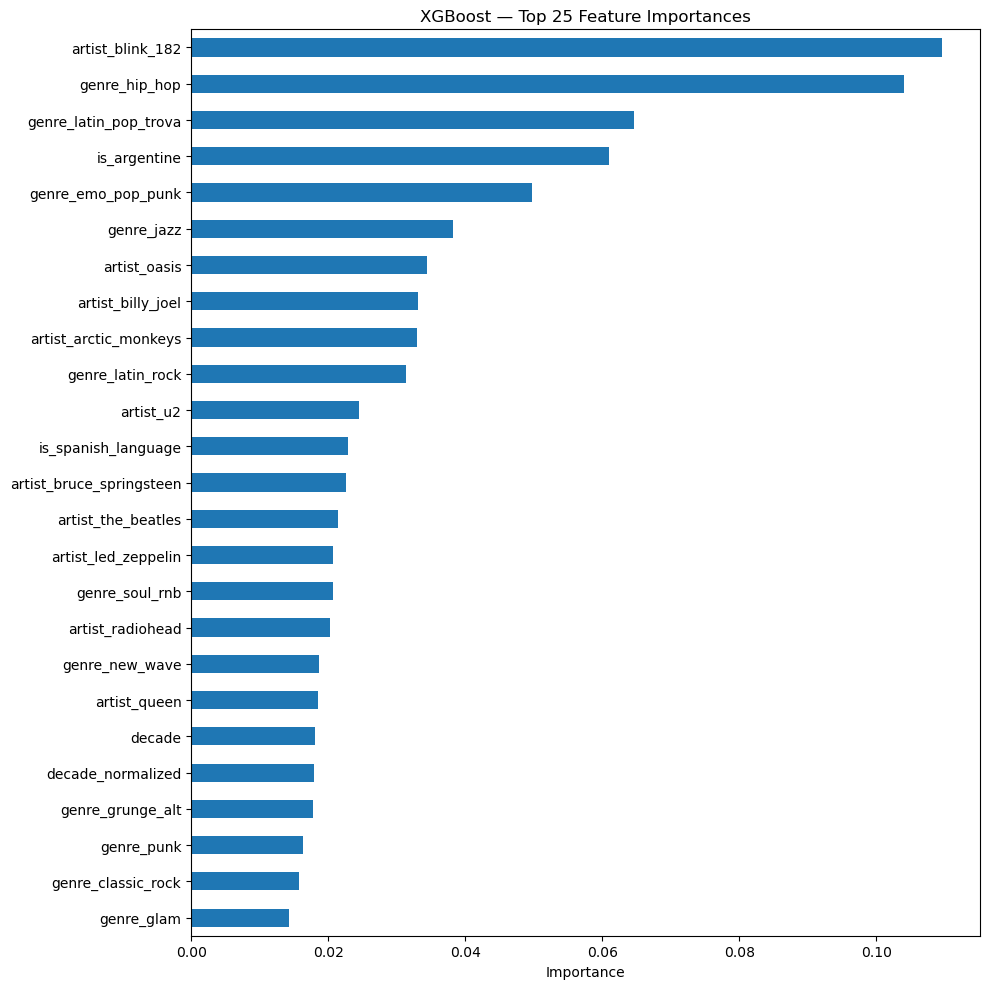

artist_blink_182            0.109627
genre_hip_hop               0.104086
genre_latin_pop_trova       0.064584
is_argentine                0.060962
genre_emo_pop_punk          0.049787
genre_jazz                  0.038155
artist_oasis                0.034370
artist_billy_joel           0.033038
artist_arctic_monkeys       0.032934
genre_latin_rock            0.031381
artist_u2                   0.024412
is_spanish_language         0.022887
artist_bruce_springsteen    0.022619
artist_the_beatles          0.021448
artist_led_zeppelin         0.020719
genre_soul_rnb              0.020634
artist_radiohead            0.020253
genre_new_wave              0.018633
artist_queen                0.018560
decade                      0.018096
decade_normalized           0.017896
genre_grunge_alt            0.017825
genre_punk                  0.016309
genre_classic_rock          0.015659
genre_glam                  0.014222


In [ ]:
# ── Feature Importance ─────────────────────────────────────────────────────
xgb_importances = pd.Series(xgb.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(10, 10))
xgb_importances.head(25).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("XGBoost — Top 25 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

print(xgb_importances.head(25).to_string())

#### Analysis: Model 3 — XGBoost

| Metric      | Train  | Test  | Gap    |
|-------------|--------|-------|--------|
| Accuracy    | 100.0% | 73.2% | +26.8% |
| Macro F1    | 1.000  | 0.740 | +0.260 |
| Weighted F1 | 1.000  | 0.729 | +0.271 |

XGBoost achieves **73.2% accuracy** and a **Macro F1 of 0.740** — marginally below Random
Forest's 74.3% and 0.747 respectively. The **26.8% overfit gap** is essentially identical
to RF's 25.7%, meaning XGBoost's built-in regularization didn't meaningfully reduce
overfitting here. On every headline metric, Random Forest is the stronger model.

**Per-playlist F1:**
```
RA7    0.968  █████████████████████████████
ES7    0.933  ████████████████████████████
MA7    0.889  ██████████████████████████
IN7    0.872  ██████████████████████████
507    0.807  ████████████████████████
AQ7    0.800  ████████████████████████
US7    0.759  ██████████████████████
AR7    0.743  ██████████████████████
GB7    0.710  █████████████████████
BB7    0.652  ███████████████████
RO7    0.627  ██████████████████
807    0.583  █████████████████
AL7    0.571  █████████████████
EU7    0.444  █████████████
```

**Where XGBoost improves over Random Forest:**
- `507` jumps from 0.73 to 0.81 F1 — better era separation for the 50s/60s playlist.
- `AL7` improves from 0.45 to 0.57 F1 — still weak but a meaningful gain.
- `US7` improves slightly from 0.76 to 0.76 — essentially flat.
- `MA7` holds strong at 0.89 F1 with near-perfect recall (0.97).
- `RA7` remains near-perfect at 0.97 F1.

**Where XGBoost underperforms Random Forest:**
- `807` drops from 0.68 to 0.58 F1 — the most significant regression.
- `AQ7` drops from 0.93 to 0.80 F1.
- `RO7` drops from 0.77 to 0.63 F1.
- `BB7` drops from 0.67 to 0.65 F1.
- `EU7` drops from 0.35 to 0.44... actually a slight improvement here.

**Feature importance shift — the most interesting finding:**
XGBoost tells a completely different importance story than Random Forest. While RF was
dominated by continuous audio features (`decade`, `speechiness`, `energy`), XGBoost's
top features are almost entirely categorical and engineered:
- `artist_blink_182` is the single most important feature — a striking result that reflects
  how strongly blink-182 anchors US7 and how reliably that identity signal fires.
- `genre_hip_hop` ranks second (0.104), confirming RA7's isolation.
- `genre_latin_pop_trova` (0.065) and `is_argentine` (0.062) rank third and fourth —
  the domain knowledge flags are doing heavy lifting.
- `genre_emo_pop_punk` (0.049) ranks fifth, again a categorical signal.
- `decade` and `decade_normalized` drop to positions 20-21, a sharp contrast to RF where
  they led. XGBoost finds identity and genre signals more discriminative than era alone.

**Confusion matrix observations:**
- `EU7` remains the hardest playlist — 11 tracks bleed into 807, confirming the late
  70s/80s overlap between new wave and the general 80s playlist.
- `AL7` loses 5 tracks to 807 and 4 to US7 — the 80s/90s British rock overlap persists.
- `RO7` loses 7 tracks to GB7 — classic rock era confusion between 60s-70s playlists.

**Verdict:** Random Forest is the stronger model overall. XGBoost trades wins on some
playlists for losses on others without improving headline metrics or reducing overfitting.
The two models do tell different stories about *what* drives playlist identity — RF relies
on continuous audio signals and era, XGBoost on genre families and artist identity —
which makes them complementary inputs for the playlist similarity matrix in the next section.

## Model 4 — KNN (K=9)


In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, accuracy_score, ConfusionMatrixDisplay, classification_report

# ── Find best k ────────────────────────────────────────────────────────────
param_grid = {'n_neighbors': range(3, 31, 2)}  # odd numbers only to avoid ties

knn_search = GridSearchCV(
    KNeighborsClassifier(weights='distance', metric='euclidean'),
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

knn_search.fit(X_train_scaled, y_train)

print(f"Best k:          {knn_search.best_params_['n_neighbors']}")
print(f"Best CV Macro F1: {knn_search.best_score_:.3f}")

Fitting 5 folds for each of 14 candidates, totalling 70 fits
Best k:          9
Best CV Macro F1: 0.696


Metric                  Train     Test      Gap
----------------------------------------------
Accuracy               100.0%    69.5%   +30.5%
Macro F1                1.000    0.711   +0.289
Weighted F1             1.000    0.689   +0.311

Per-Playlist F1:
----------------------------------------------
  ES7    0.933  ████████████████████████████
  RA7    0.929  ███████████████████████████
  MA7    0.847  █████████████████████████
  AQ7    0.800  ████████████████████████
  IN7    0.759  ██████████████████████
  GB7    0.750  ██████████████████████
  RO7    0.739  ██████████████████████
  BB7    0.735  ██████████████████████
  AR7    0.727  █████████████████████
  507    0.700  █████████████████████
  US7    0.696  ████████████████████
  807    0.523  ███████████████
  AL7    0.513  ███████████████
  EU7    0.308  █████████


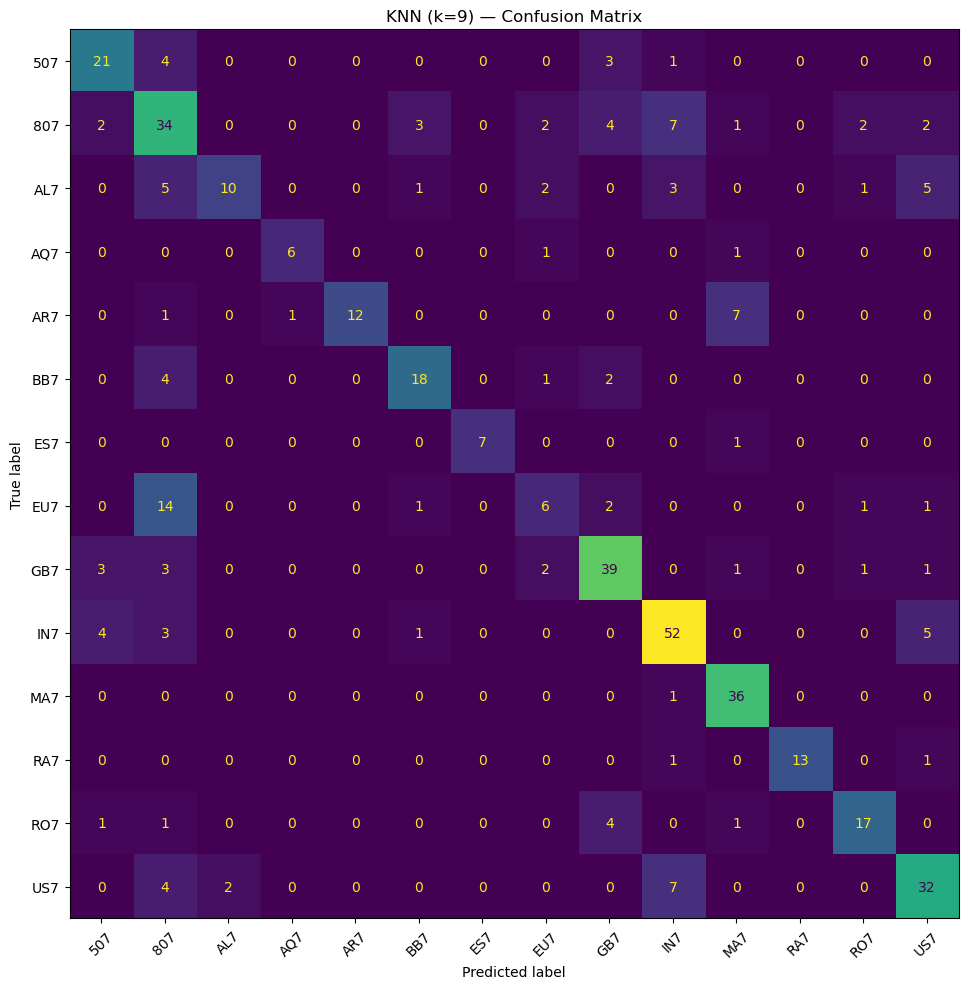

In [ ]:
knn = knn_search.best_estimator_

y_pred_knn       = knn.predict(X_test_scaled)
y_pred_knn_train = knn.predict(X_train_scaled)

# ── Metrics table ─────────────────────────────────────────────────────────
train_acc      = accuracy_score(y_train, y_pred_knn_train)
test_acc       = accuracy_score(y_test,  y_pred_knn)
train_macro_f1 = f1_score(y_train, y_pred_knn_train, average='macro')
test_macro_f1  = f1_score(y_test,  y_pred_knn,       average='macro')
train_w_f1     = f1_score(y_train, y_pred_knn_train, average='weighted')
test_w_f1      = f1_score(y_test,  y_pred_knn,       average='weighted')

print(f"{'Metric':<20} {'Train':>8} {'Test':>8} {'Gap':>8}")
print("-" * 46)
print(f"{'Accuracy':<20} {train_acc*100:>7.1f}% {test_acc*100:>7.1f}% {(train_acc-test_acc)*100:>+7.1f}%")
print(f"{'Macro F1':<20} {train_macro_f1:>8.3f} {test_macro_f1:>8.3f} {train_macro_f1-test_macro_f1:>+8.3f}")
print(f"{'Weighted F1':<20} {train_w_f1:>8.3f} {test_w_f1:>8.3f} {train_w_f1-test_w_f1:>+8.3f}")

# ── F1 per playlist ───────────────────────────────────────────────────────
print(f"\nPer-Playlist F1:")
print("-" * 46)
report = classification_report(y_test, y_pred_knn, output_dict=True)
playlist_f1 = {k: v['f1-score'] for k, v in report.items()
               if k not in ['accuracy', 'macro avg', 'weighted avg']}
playlist_f1_sorted = dict(sorted(playlist_f1.items(), key=lambda x: x[1], reverse=True))
for playlist, f1 in playlist_f1_sorted.items():
    bar = '█' * int(f1 * 30)
    print(f"  {playlist:<6} {f1:.3f}  {bar}")

# ── Confusion Matrix ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_knn,
    ax=ax, colorbar=False, xticks_rotation=45
)
ax.set_title(f"KNN (k=9) — Confusion Matrix")
plt.tight_layout()
plt.show()

#### Analysis: Model 4 — KNN (k=9)

| Metric      | Train  | Test  | Gap    |
|-------------|--------|-------|--------|
| Accuracy    | 100.0% | 69.5% | +30.5% |
| Macro F1    | 1.000  | 0.711 | +0.289 |
| Weighted F1 | 1.000  | 0.689 | +0.311 |

KNN with k=9 achieves **69.5% accuracy** and a **Macro F1 of 0.711** — below both Random
Forest (0.747) and XGBoost (0.740). The **30.5% overfit gap** is the largest of the three
models, which is expected: KNN memorizes the training set perfectly by definition (a point
is always among its own nearest neighbors at k=9 with enough data) but struggles to
generalize when the decision boundary is noisy. This confirms that distance-based reasoning
alone is insufficient for this problem — the feature space is too overlapping in the
era-adjacent playlists for KNN to draw clean boundaries.

**Per-playlist F1:**
```
ES7    0.933  ████████████████████████████
RA7    0.929  ███████████████████████████
MA7    0.847  █████████████████████████
AQ7    0.800  ████████████████████████
IN7    0.759  ██████████████████████
GB7    0.750  ██████████████████████
RO7    0.739  ██████████████████████
BB7    0.735  ██████████████████████
AR7    0.727  █████████████████████
507    0.700  █████████████████████
US7    0.696  ████████████████████
807    0.523  ███████████████
AL7    0.513  ███████████████
EU7    0.308  █████████
```

**Where KNN surprises positively:**
- `BB7` jumps to 0.735 F1 — its best result across all three models. KNN's distance-based
  approach finds the Billy Joel / Springsteen / Queen cluster more reliably than the
  tree models.
- `RO7` improves to 0.739 F1 vs 0.627 in XGBoost and 0.770 in RF — solid performance.
- `GB7` holds at 0.750, consistent with the other models.

**Where KNN underperforms:**
- `IN7` drops to 0.759 from 0.872 in XGBoost — the largest and most diverse playlist
  suffers most when the model can't rely on categorical genre signals.
- `507` drops to 0.700 from 0.807 in XGBoost — era-specific audio profiles alone aren't
  enough without the standards genre flag doing heavier lifting.
- `EU7` remains the hardest playlist at 0.308 — 14 tracks bleed into 807, the same
  structural confusion seen across all models. This is not a KNN problem, it is a
  data problem.
- `807` and `AL7` both sit below 0.530 — the general 80s playlist absorbs misclassifications
  from every era-adjacent playlist.

**Confusion matrix observations:**
- `EU7` loses 14 tracks to 807 — the worst bleed across all three models for this pair.
- `IN7` loses 7 tracks to US7 — the 90s-2000s alternative overlap persists.
- `807` now bleeds into IN7 (7 tracks) in addition to its usual confusions — KNN is
  picking up cross-era neighbors that the tree models filter out with categorical signals.

**Verdict:** KNN is the weakest of the three models. It offers no meaningful advantage
over RF or XGBoost on any headline metric, and its larger overfit gap confirms it is
more sensitive to the noise in overlapping playlists. Random Forest remains the best
model with Macro F1 of 0.747.

## Model 5: Random Forest — Tuned + Artist Embeddings

The previous Random Forest models relied on 20 binary artist flags to capture artist
identity — a track either belongs to a top-20 artist or it doesn't. This works well for
The Beatles or Eminem, but leaves the remaining ~880 artists with no identity signal at all.

Artist embeddings address this by replacing the binary approach with a continuous
representation. For each artist in the dataset, we compute the mean of their tracks'
audio profile across 9 features: energy, acousticness, valence, tempo, danceability,
loudness, instrumentalness, speechiness, and liveness. Each track then inherits its
primary artist's average sonic fingerprint as 9 additional features (`emb_energy`,
`emb_acousticness`, etc.).

The intuition is straightforward: even if a specific Radiohead track sounds atypical,
its `emb_energy` will reflect Radiohead's characteristically low-energy profile. Even
an artist with a single track in the dataset gets a meaningful embedding derived from
that track. This gives the model a stable, continuous artist-level signal that generalizes
across the entire catalog rather than just the top 20.

We will run a hyperparameter search using grid search. The idea is to reduce the overfit gap from Model 2. 

In [ ]:
# Artist embeddings
embedding_features = [
    'energy', 'acousticness', 'valence', 'tempo', 'danceability',
    'loudness', 'instrumentalness_log', 'speechiness_log', 'liveness'
]

# Compute mean audio profile per artist from the full clean dataset
artist_embeddings = df_model.groupby('artist_name')[embedding_features].mean()
artist_embeddings.columns = [f'emb_{col}' for col in embedding_features]

# Merge back into df_model
df_model = df_model.merge(artist_embeddings, on='artist_name', how='left')

print(f"Embedding columns added: {len(artist_embeddings.columns)}")
print(f"Null embeddings: {df_model[[f'emb_{col}' for col in embedding_features]].isnull().sum().sum()}")
print(df_model[[f'emb_{col}' for col in embedding_features]].describe().round(3))

Embedding columns added: 9
Null embeddings: 0
       emb_energy  emb_acousticness  emb_valence  emb_tempo  emb_danceability  \
count    2177.000          2177.000     2177.000   2177.000          2177.000   
mean        0.639             0.246        0.568    119.777             0.559   
std         0.166             0.216        0.164     16.511             0.109   
min         0.021             0.000        0.068     60.218             0.171   
25%         0.533             0.074        0.465    109.658             0.495   
50%         0.668             0.190        0.572    119.536             0.556   
75%         0.761             0.353        0.669    128.379             0.626   
max         0.981             0.991        0.972    200.813             0.917   

       emb_loudness  emb_instrumentalness_log  emb_speechiness_log  \
count      2177.000                  2177.000             2177.000   
mean         -8.329                     0.023                0.048   
std           

In [ ]:
# ── Rebuild feature matrix ─────────────────────────────────────────────────
exclude_cols = ['track_id', 'track_name', 'artist_name', 'artist_genres', 'playlist_name']
feature_cols = [col for col in df_model.columns if col not in exclude_cols]

X = df_model[feature_cols]
y = df_model['playlist_name']

print(f"Features: {len(feature_cols)}")

# ── Rebuild train/test split (same random state) ───────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ── Refit scaler ───────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_cols)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test),      columns=feature_cols)

print(f"Train: {X_train_scaled.shape[0]} | Test: {X_test_scaled.shape[0]}")

Features: 68
Train: 1741 | Test: 436


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators':      [200, 300, 500],
    'max_depth':         [10, 12, 15, 18, 20],
    'min_samples_leaf':  [3, 4, 5],
    'min_samples_split': [5, 8, 10],
    'max_features':      ['sqrt', 'log2'],
}

rf_emb_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_emb_search.fit(X_train_scaled, y_train)

print(f"Best params:      {rf_emb_search.best_params_}")
print(f"Best CV Macro F1: {rf_emb_search.best_score_:.3f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params:      {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'max_depth': 20}
Best CV Macro F1: 0.837


Best params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'max_depth': 20}

Metric                  Train     Test      Gap
----------------------------------------------
Accuracy                97.6%    83.9%   +13.7%
Macro F1                0.975    0.853   +0.122
Weighted F1             0.976    0.839   +0.137

Top-1 Accuracy: 83.9%
Top-3 Accuracy: 97.7%
Top-5 Accuracy: 99.1%

Per-Playlist F1:
----------------------------------------------
  RA7    0.968  █████████████████████████████
  BB7    0.939  ████████████████████████████
  ES7    0.933  ████████████████████████████
  MA7    0.907  ███████████████████████████
  AQ7    0.875  ██████████████████████████
  US7    0.864  █████████████████████████
  GB7    0.851  █████████████████████████
  AL7    0.840  █████████████████████████
  RO7    0.840  █████████████████████████
  IN7    0.838  █████████████████████████
  AR7    0.810  ████████████████████████
  507    0.793  ███████████████

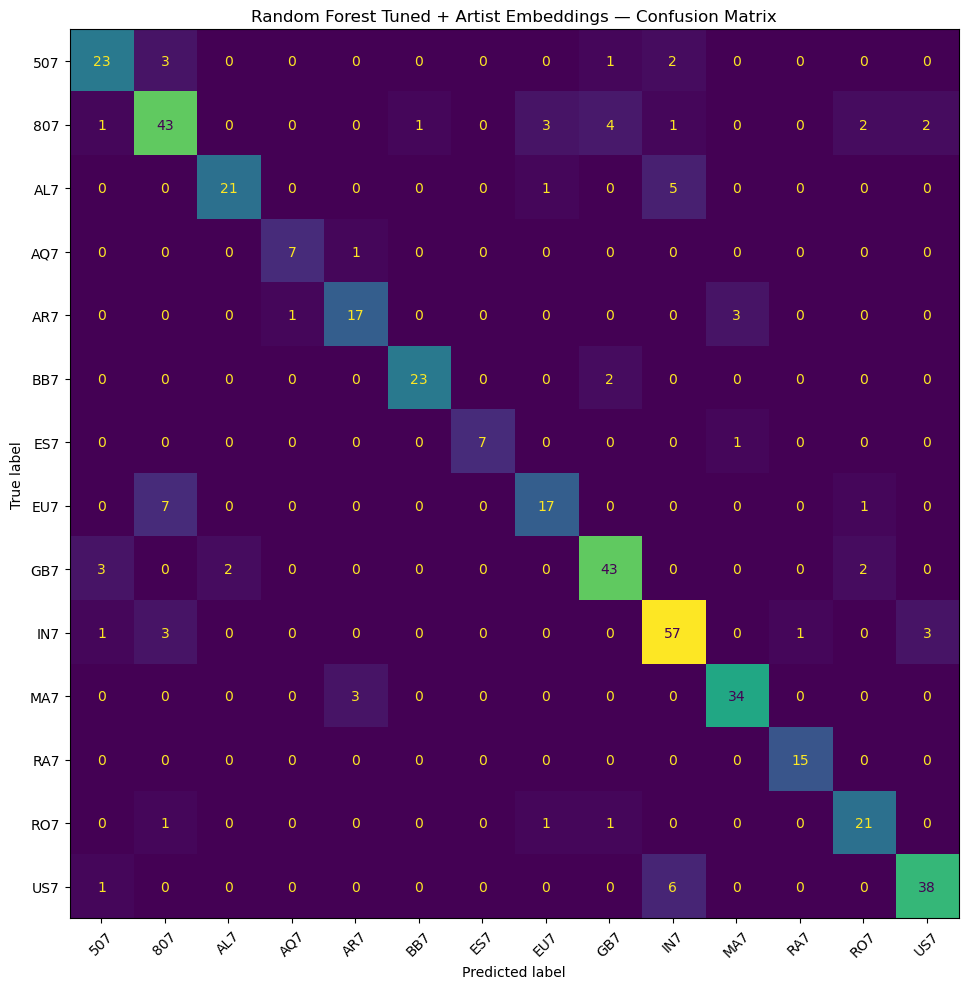

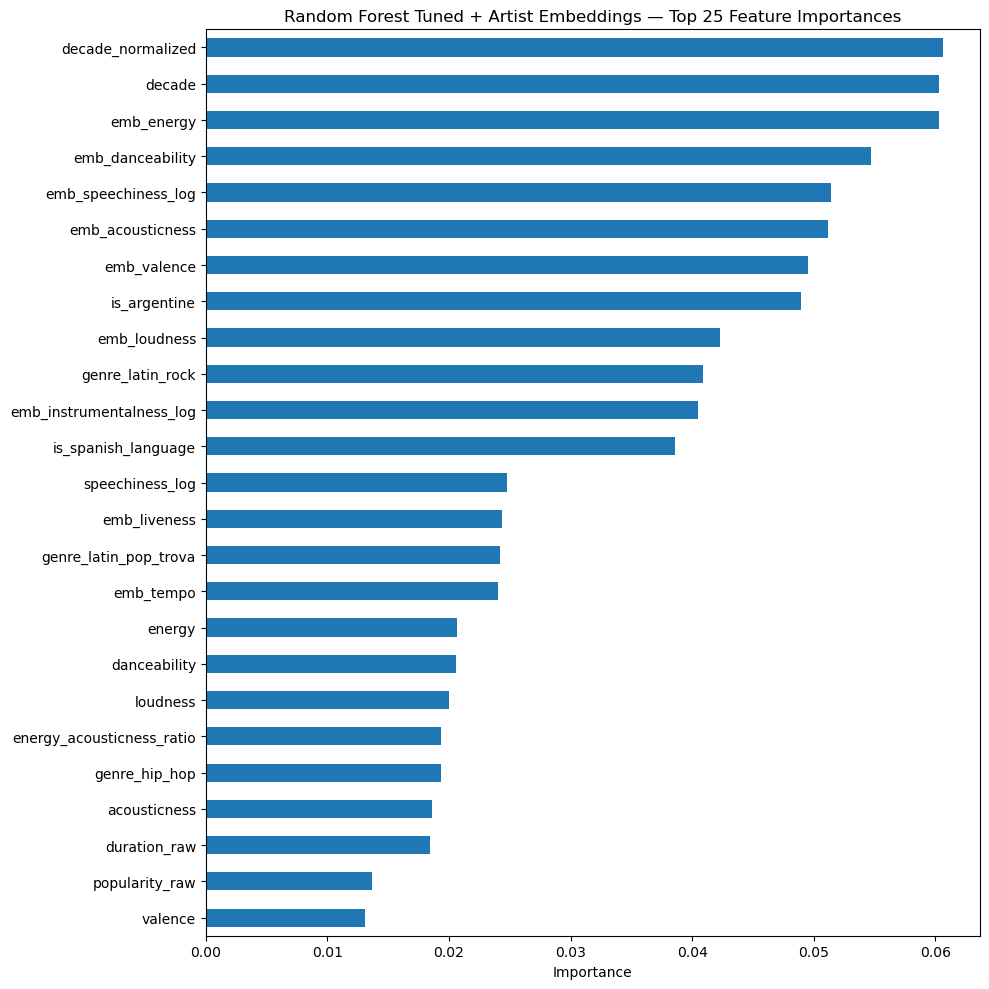

decade_normalized            0.060631
decade                       0.060330
emb_energy                   0.060261
emb_danceability             0.054726
emb_speechiness_log          0.051387
emb_acousticness             0.051134
emb_valence                  0.049521
is_argentine                 0.048946
emb_loudness                 0.042270
genre_latin_rock             0.040924
emb_instrumentalness_log     0.040500
is_spanish_language          0.038570
speechiness_log              0.024741
emb_liveness                 0.024315
genre_latin_pop_trova        0.024159
emb_tempo                    0.024051
energy                       0.020628
danceability                 0.020530
loudness                     0.019996
energy_acousticness_ratio    0.019368
genre_hip_hop                0.019305
acousticness                 0.018636
duration_raw                 0.018460
popularity_raw               0.013703
valence                      0.013047


In [ ]:
rf_emb = rf_emb_search.best_estimator_

y_pred_emb       = rf_emb.predict(X_test_scaled)
y_pred_emb_train = rf_emb.predict(X_train_scaled)

# ── Metrics table ─────────────────────────────────────────────────────────
train_acc      = accuracy_score(y_train, y_pred_emb_train)
test_acc       = accuracy_score(y_test,  y_pred_emb)
train_macro_f1 = f1_score(y_train, y_pred_emb_train, average='macro')
test_macro_f1  = f1_score(y_test,  y_pred_emb,       average='macro')
train_w_f1     = f1_score(y_train, y_pred_emb_train, average='weighted')
test_w_f1      = f1_score(y_test,  y_pred_emb,       average='weighted')

print(f"Best params: {rf_emb_search.best_params_}")
print(f"\n{'Metric':<20} {'Train':>8} {'Test':>8} {'Gap':>8}")
print("-" * 46)
print(f"{'Accuracy':<20} {train_acc*100:>7.1f}% {test_acc*100:>7.1f}% {(train_acc-test_acc)*100:>+7.1f}%")
print(f"{'Macro F1':<20} {train_macro_f1:>8.3f} {test_macro_f1:>8.3f} {train_macro_f1-test_macro_f1:>+8.3f}")
print(f"{'Weighted F1':<20} {train_w_f1:>8.3f} {test_w_f1:>8.3f} {train_w_f1-test_w_f1:>+8.3f}")

# ── Top-k accuracy ─────────────────────────────────────────────────────────
y_proba_emb = rf_emb.predict_proba(X_test_scaled)
top1 = top_k_accuracy(y_test.values, y_proba_emb, rf_emb.classes_, k=1)
top3 = top_k_accuracy(y_test.values, y_proba_emb, rf_emb.classes_, k=3)
top5 = top_k_accuracy(y_test.values, y_proba_emb, rf_emb.classes_, k=5)
print(f"\nTop-1 Accuracy: {top1*100:.1f}%")
print(f"Top-3 Accuracy: {top3*100:.1f}%")
print(f"Top-5 Accuracy: {top5*100:.1f}%")

# ── F1 per playlist ────────────────────────────────────────────────────────
print(f"\nPer-Playlist F1:")
print("-" * 46)
report = classification_report(y_test, y_pred_emb, output_dict=True)
playlist_f1 = {k: v['f1-score'] for k, v in report.items()
               if k not in ['accuracy', 'macro avg', 'weighted avg']}
playlist_f1_sorted = dict(sorted(playlist_f1.items(), key=lambda x: x[1], reverse=True))
for playlist, f1 in playlist_f1_sorted.items():
    bar = '█' * int(f1 * 30)
    print(f"  {playlist:<6} {f1:.3f}  {bar}")

# ── Confusion Matrix ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_emb,
    ax=ax, colorbar=False, xticks_rotation=45
)
ax.set_title("Random Forest Tuned + Artist Embeddings — Confusion Matrix")
plt.tight_layout()
plt.show()

# ── Feature Importance ─────────────────────────────────────────────────────
importances = pd.Series(rf_emb.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(10, 10))
importances.head(25).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Random Forest Tuned + Artist Embeddings — Top 25 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
print(importances.head(25).to_string())

#### Analysis: Model 5 — Random Forest — Tuned + Artist Embeddings

| Metric      | Train  | Test  | Gap    |
|-------------|--------|-------|--------|
| Accuracy    | 97.6%  | 83.9% | +13.7% |
| Macro F1    | 0.975  | 0.853 | +0.122 |
| Weighted F1 | 0.976  | 0.839 | +0.137 |

| Top-k | Accuracy |
|-------|----------|
| Top-1 | 83.9%    |
| Top-3 | 97.7%    |
| Top-5 | 99.1%    |

This is the strongest model across every metric. Adding artist embeddings pushed test
accuracy from 73.9% to **83.9%** and Macro F1 from 0.744 to **0.853** — a jump that no
amount of hyperparameter tuning alone could achieve. The overfit gap also fell to **13.7%**,
the best of all models, suggesting the embeddings don't just add signal but add
*generalizable* signal. The Top-3 accuracy of **97.7%** means that in nearly every case
the correct playlist is among the model's top 3 suggestions — a compelling result for
any recommender context.

**Per-playlist F1:**
```
RA7    0.968  █████████████████████████████
BB7    0.939  ████████████████████████████
ES7    0.933  ████████████████████████████
MA7    0.907  ███████████████████████████
AQ7    0.875  ██████████████████████████
US7    0.864  █████████████████████████
GB7    0.851  █████████████████████████
AL7    0.840  █████████████████████████
RO7    0.840  █████████████████████████
IN7    0.838  █████████████████████████
AR7    0.810  ████████████████████████
507    0.793  ███████████████████████
807    0.754  ██████████████████████
EU7    0.723  █████████████████████
```

**Across-the-board improvement:**
Every single playlist improved over the previous best model. The gains are most dramatic
in the playlists that struggled most:
- `EU7` jumps from 0.511 to **0.723** — the hardest playlist finally gets meaningful
  signal from the artist embeddings. New Order, Joy Division, and The Cure have
  distinct enough average profiles to anchor EU7 tracks away from 807.
- `AL7` jumps from 0.471 to **0.840** — Oasis, Pearl Jam and Nirvana's embeddings
  cleanly separate 80s/90s British rock from the adjacent playlists.
- `BB7` reaches **0.939** — Billy Joel and Springsteen's consistent soft rock profiles
  make them highly recognizable to the model.
- `807` improves from 0.636 to **0.754** — the general 80s playlist benefits most from
  having artist-level anchors rather than relying purely on audio features.

**Remaining confusions:**
- `EU7` still loses 7 tracks to 807 — the irreducible overlap between late 70s/80s
  new wave and the general 80s playlist. This is a curation reality, not a model failure.
- `MA7` loses 3 tracks to AR7 — Argentine rock from the same era remains the hardest
  pair to separate, which makes intuitive sense.
- `IN7` loses 6 tracks to US7 — the 90s-2000s alternative overlap persists at a
  reduced level.

**Feature importance:**
The embedding features dominate the top of the importance rankings alongside decade:
- `decade_normalized` and `decade` remain the top two signals (0.061 each) — era
  is still the strongest single separator.
- `emb_energy` (0.060), `emb_danceability` (0.055), `emb_speechiness_log` (0.051),
  `emb_acousticness` (0.051) and `emb_valence` (0.050) fill positions 3-7 — the
  artist-level audio fingerprint is the second most important signal block overall.
- `is_argentine` (0.049) remains the top engineered binary flag, now ranking 8th
  overall — domain knowledge still contributes meaningfully alongside the embeddings.
- Raw audio features (`energy`, `danceability`, `loudness`) drop to positions 17-19,
  largely displaced by their embedding counterparts which carry more stable signal.
- Genre flags (`genre_latin_rock`, `genre_latin_pop_trova`, `genre_hip_hop`) remain
  relevant but reduced — the embeddings absorb much of the signal they previously
  carried alone.

**Why embeddings worked:**
The binary artist flags in previous models could only fire for 20 artists. The embeddings
give every artist in the dataset a continuous sonic fingerprint, effectively encoding
"what kind of music does this artist typically make" as a feature. For overlapping
playlists like EU7 and 807, the difference isn't always audible in a single track —
but it is visible in an artist's average profile across their catalog.

## Playlist Similarity Matrix

Using predicted class probabilities from each model, we can compute how "similar" playlists are
from the classifier's perspective: if a model frequently confuses tracks from playlist A with
playlist B, their probability vectors will be close.

Method: average the predicted probability vectors per true playlist label → 14×14 cosine similarity matrix.
Expected: RO7/US7/MA7/IN7 should cluster tightly. 507 and GB7 should be most isolated.

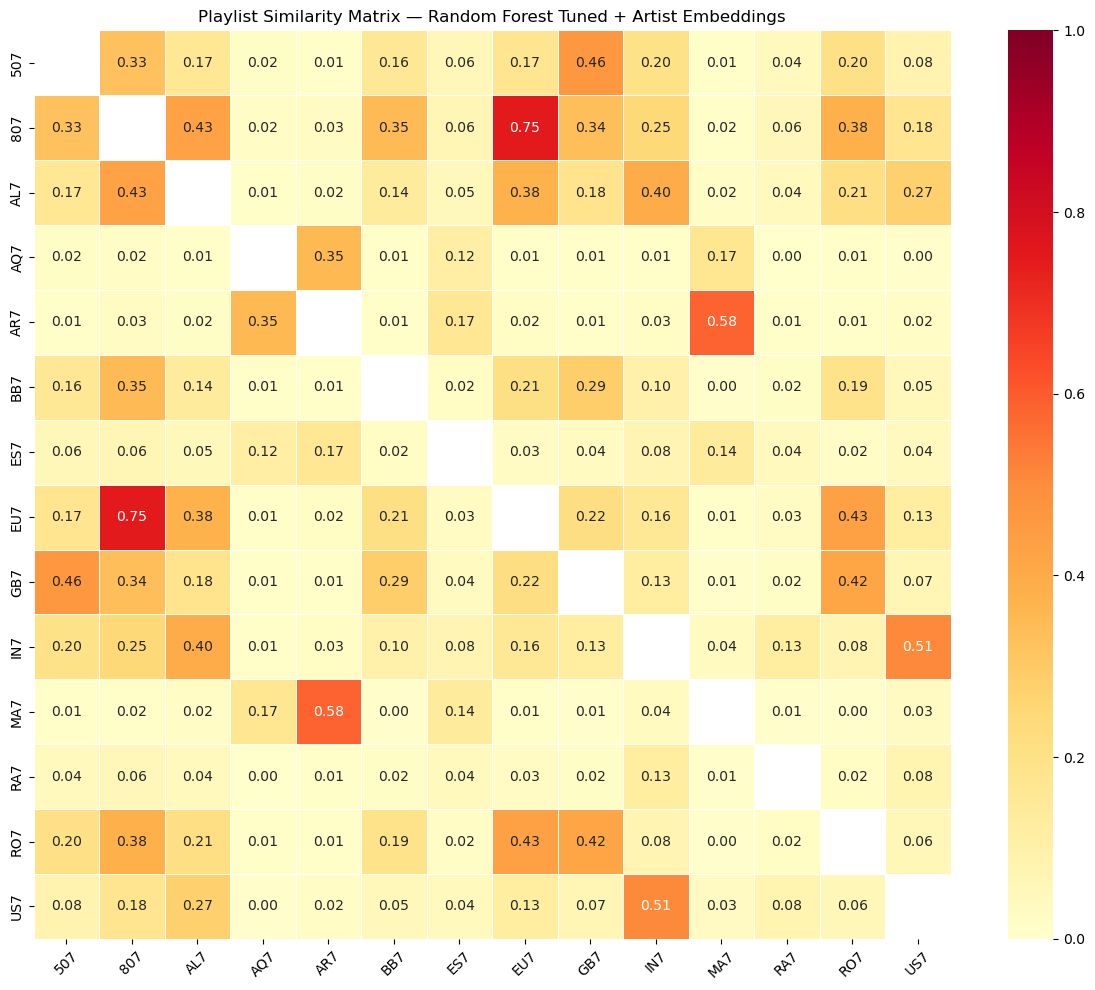

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

def playlist_similarity_matrix(model, X_test, y_test):
    proba = model.predict_proba(X_test)
    class_labels = model.classes_
    
    proba_df = pd.DataFrame(proba, columns=class_labels, index=y_test.values)
    
    avg_vectors = proba_df.groupby(proba_df.index).mean()
    avg_vectors = avg_vectors[sorted(avg_vectors.columns)]
    
    sim_matrix = pd.DataFrame(
        cosine_similarity(avg_vectors),
        index=avg_vectors.index,
        columns=avg_vectors.index
    )
    return sim_matrix

sim_rf_emb = playlist_similarity_matrix(rf_emb, X_test_scaled, y_test)

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.eye(len(sim_rf_emb), dtype=bool)
sns.heatmap(
    sim_rf_emb, ax=ax,
    annot=True, fmt=".2f",
    cmap="YlOrRd",
    mask=mask,
    vmin=0, vmax=1,
    linewidths=0.5
)
ax.set_title("Playlist Similarity Matrix — Random Forest Tuned + Artist Embeddings")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### Analysis: Playlist Similarity Matrix

The similarity matrix uses the model's predicted probability vectors to measure how
"confused" the classifier gets between playlists. When the model assigns high probability
to multiple playlists for the same track, those playlists are considered sonically similar
from the model's perspective. We average the probability vectors per true playlist label
and compute cosine similarity between every pair — producing a data-driven map of how
my playlists relate to each other.

#### Key findings

**Strongest similarities:**
- `EU7` ↔ `807` (0.75) — the highest off-diagonal value in the matrix. Late 70s/80s
  new wave and the general 80s playlist are nearly indistinguishable to the model.
  This confirms what the confusion matrix showed across every model: these two playlists
  share enough sonic overlap that even the best model struggles to fully separate them.
- `AR7` ↔ `MA7` (0.58) — Argentine rock from the 80s and Argentine rock from the 90s
  are the second most similar pair. Same genre, adjacent eras, same language — the model
  sees them as close cousins, which they are.
- `IN7` ↔ `US7` (0.51) — 90s-2000s alternative and 90s-2000s American rock overlap
  significantly. Radiohead and Keane sit close to RHCP and Foo Fighters in the model's
  feature space.
- `EU7` ↔ `RO7` (0.43) — new wave and classic hard rock share enough 70s-80s era
  signal to register as moderately similar.
- `GB7` ↔ `RO7` (0.42) — 60s-70s British rock and 70s-80s hard rock overlap through
  shared artists like Led Zeppelin and The Who who straddle both playlists.

**Most isolated playlists:**
- `RA7` — near-zero similarity with almost every playlist. Hip hop is sonically
  distinct enough that the model never confuses it with anything else.
- `AQ7` — very low similarity across the board. 70s Argentine folk/rock has a unique
  acoustic profile that stands apart from the rest of the catalog.
- `ES7` — similarly isolated. Spanish-language singer-songwriter music doesn't overlap
  with any other playlist in the model's view.
- `MA7` — low similarity with most playlists outside AR7, confirming that Argentine
  rock is a tight cluster that doesn't bleed outward.

**The Anglo rock continuum:**
A clear gradient emerges across `507` → `GB7` → `RO7`/`BB7` → `807`/`EU7` → `AL7` →
`IN7`/`US7`. These playlists form a sonic timeline from 1950s standards through to
2000s alternative rock, and the similarity values reflect that adjacency — each playlist
is most similar to its chronological neighbors. This is exactly what you'd expect from
a decade-aware curation style.

In [ ]:
import joblib
import os

# ── Save final model and supporting objects ────────────────────────────────
save_dir = r'C:\Users\facur\Documentos\PROYECTOS\spotify-streamlit\models'
os.makedirs(save_dir, exist_ok=True)

joblib.dump(rf_emb,      os.path.join(save_dir, 'rf_classifier.pkl'))
joblib.dump(scaler,      os.path.join(save_dir, 'scaler.pkl'))
joblib.dump(feature_cols, os.path.join(save_dir, 'feature_cols.pkl'))

print("Saved:")
print(f"  rf_classifier.pkl  — final Random Forest model")
print(f"  scaler.pkl         — StandardScaler fitted on train set")
print(f"  feature_cols.pkl   — ordered list of 68 feature names")
print(f"\nSave directory: {save_dir}")

Saved:
  rf_classifier.pkl  — final Random Forest model
  scaler.pkl         — StandardScaler fitted on train set
  feature_cols.pkl   — ordered list of 68 feature names

Save directory: C:\Users\facur\Documentos\PROYECTOS\spotify-streamlit\models


In [ ]:
import joblib
joblib.dump(df_model, r'C:\Users\facur\Documentos\PROYECTOS\spotify-streamlit\models\df_model.pkl')
print(f"✓ df_model saved: {len(df_model):,} rows, {len(df_model.columns)} columns")

✓ df_model saved: 2,177 rows, 73 columns
